### **Importação dos arquivos**

Foi realizada a importação de toda a série histórica a partir de **01/08/1994**.  
No entanto, o primeiro arquivo disponível continha dados apenas até **10/10/2014**.

Para contornar essa limitação, importei um segundo arquivo contendo o período mais recente e, em seguida, realizei a junção dos dois conjuntos de dados.

Após a consolidação, passei a trabalhar com uma série histórica completa, abrangendo o período de **01/08/1994 até 01/08/2025**.


In [ ]:
#####################################################################
# BLOCO 1 — IMPORTAÇÃO E CONSOLIDAÇÃO DOS DADOS
#####################################################################

# Importa biblioteca
import pandas as pd

# URLs das bases históricas do IBOVESPA (01.01.2024 - 13.05.2026)
url1 = "https://raw.githubusercontent.com/tivanello/fase2/main/data/raw/Dados%20Hist%C3%B3ricos%20-%20Ibovespa%2011-10-2014%2016-09-2025.csv"
url2 = "https://raw.githubusercontent.com/tivanello/fase2/main/data/raw/Dados%20Hist%C3%B3ricos%20-%20Ibovespa%201994%2010-10-2014.csv"

# Leitura dos arquivos CSV
# A coluna Data é forçada como string para evitar interpretação incorreta pelo pandas
df1 = pd.read_csv(url1, thousands='.', decimal=',', dtype={'Data': str})
df2 = pd.read_csv(url2, thousands='.', decimal=',', dtype={'Data': str})

# Concatenação das bases
df_ibovespa = pd.concat([df1, df2], ignore_index=True)

# Visualizações iniciais
print("Primeiras linhas:")
print(df_ibovespa.head())

print("\nDimensão da base:")
print(df_ibovespa.shape)

print("\nInformações gerais:")
print(df_ibovespa.info())




Primeiras linhas:
         Data  Último  Abertura  Máxima  Mínima   Vol.    Var%
0  16.09.2025  144062    143547  144584  143547  8,48B   0,36%
1  15.09.2025  143547    142292  144194  142292  6,61B   0,90%
2  12.09.2025  142272    143151  143202  142241  6,39B  -0,61%
3  11.09.2025  143151    142349  144013  142349  7,57B   0,56%
4  10.09.2025  142349    141612  143182  141612  7,14B   0,52%

Dimensão da base:
(7711, 7)

Informações gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7711 entries, 0 to 7710
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Data      7711 non-null   object
 1   Último    7711 non-null   int64 
 2   Abertura  7711 non-null   int64 
 3   Máxima    7711 non-null   int64 
 4   Mínima    7711 non-null   int64 
 5   Vol.      7710 non-null   object
 6   Var%      7711 non-null   object
dtypes: int64(4), object(3)
memory usage: 421.8+ KB
None


### **Verificação do Bloco 1 — Resultado da importação**

**verificações:**
- A coluna **Data** foi preservada como texto, permitindo controle da conversão posterior para datetime;
- As colunas de preços (**Último**, **Abertura**, **Máxima**, **Mínima**) foram lidas corretamente como variáveis numéricas;
- A coluna **Vol.** foi identificada como texto, o que é esperado devido à presença de sufixos como bilhões e milhões;
- A coluna **Var%** também foi mantida como texto por conter o símbolo percentual;
- Foi identificado apenas 1 valor ausente na coluna **Vol.**

**Conclusão:**
A base foi carregada corretamente e está pronta para a etapa de padronização dos nomes das colunas e tratamento das variáveis.

In [ ]:
#####################################################################
# BLOCO 2 — PADRONIZAÇÃO DOS NOMES DAS COLUNAS
#####################################################################

df_ibovespa = df_ibovespa.rename(
    columns={
        'Data': 'data',
        'Último': 'fechamento',
        'Abertura': 'abertura',
        'Máxima': 'maxima',
        'Mínima': 'minima',
        'Vol.': 'volume',
        'Var%': 'variacao'
    }
)

# Visualização inicial
df_ibovespa.head()

,data,fechamento,abertura,maxima,minima,volume,variacao
0,16.09.2025,144062,143547,144584,143547,"8,48B","0,36%"
1,15.09.2025,143547,142292,144194,142292,"6,61B","0,90%"
2,12.09.2025,142272,143151,143202,142241,"6,39B","-0,61%"
3,11.09.2025,143151,142349,144013,142349,"7,57B","0,56%"
4,10.09.2025,142349,141612,143182,141612,"7,14B","0,52%"


### **Bloco 2 — Padronização dos nomes das colunas**

**Objetivo:**
Padronizar os nomes das colunas para facilitar a manipulação e análise dos dados ao longo do projeto.

**Ajustes realizados:**
- Tradução e padronização dos nomes para minúsculo;
- Substituição de caracteres especiais por nomes simples e consistentes;
- Uso de nomenclatura mais clara para séries temporais financeiras (ex: atereração de Último para **fechamento**).

**Observação:**
A coluna **variacao** ainda está no formato percentual como string (ex: "0,45%") e será tratada posteriormente para conversão em valor numérico.

In [ ]:
#####################################################################
# BLOCO 3 — TRATAMENTO DA COLUNA DE DATA E ORDENAÇÃO TEMPORAL
#####################################################################

# Converte a coluna de data para datetime (formato brasileiro)
df_ibovespa['data'] = pd.to_datetime(df_ibovespa['data'], dayfirst=True)

# Ordena cronologicamente (ESSENCIAL para séries temporais)
df_ibovespa = df_ibovespa.sort_values(by='data').reset_index(drop=True)

# Verificação
df_ibovespa.head()


,data,fechamento,abertura,maxima,minima,volume,variacao
0,1994-08-01,4152,4201,4223,4091,"5,39B","-1,17%"
1,1994-08-02,4311,4152,4311,4152,"6,63B","3,83%"
2,1994-08-03,4392,4311,4426,4275,"6,88B","1,88%"
3,1994-08-04,4355,4392,4406,4321,"5,67B","-0,84%"
4,1994-08-05,4470,4355,4476,4329,"5,14B","2,64%"


### **Bloco 3 — Tratamento da coluna de data e ordenação temporal**

**Objetivo:**
Garantir que a coluna **data** esteja no formato correto para análise temporal e que os registros estejam organizados em ordem cronológica.

**O que foi feito:**
- Conversão da coluna data para o tipo datetime, respeitando o formato brasileiro (dia/mês/ano) por meio do parâmetro **dayfirst=True**;
- Ordenação crescente da base pela coluna **data**;
- Reset do índice para manter a sequência consistente após a ordenação.

**Observação:**

- A ordenação temporal é uma etapa crítica em séries temporais, pois garante a consistência de cálculos futuros, como retornos, criação de variáveis defasadas (**lags**), janelas móveis (**rolling windows**) e divisão entre treino e teste.

In [ ]:
#####################################################################
# BLOCO 4 — CONVERSÃO DA VARIAÇÃO PERCENTUAL PARA NUMÉRICO
#####################################################################

df_ibovespa["variacao_num"] = (
    df_ibovespa["variacao"].astype(str)
        .str.replace("%", "", regex=False)
        .str.replace(",", ".", regex=False)
        .pipe(pd.to_numeric, errors='coerce') / 100.0
)

# Verificação
df_ibovespa[["variacao", "variacao_num"]].head()




,variacao,variacao_num
0,"-1,17%",-0.0117
1,"3,83%",0.0383
2,"1,88%",0.0188
3,"-0,84%",-0.0084
4,"2,64%",0.0264


###  **Bloco 4 — Conversão da variação percentual para formato numérico**

**Objetivo:**
- Criar uma coluna **variacao_num**, usando a coluna variação que originalmente esta em formato percentual (**string**), em uma variável numérica adequada para análise e modelagem.

**Etapas realizadas:**
- Remoção do símbolo de porcentagem (**%**);
- Conversão do separador decimal de vírgula para ponto;
- Conversão dos valores para tipo numérico (**float**);
- Transformação da escala percentual para decimal (divisão por 100).

**Exemplo:**
- "2,64%" → 0.0264  
- "-0,84%" → -0.0084  

**Observação:**
- Os Valores inválidos, caso existam, foram convertidos para **NaN** evitando erro no processamento e permitir tratamento posterior.

In [ ]:
#####################################################################
# BLOCO 5 — CONVERSÃO DO VOLUME PARA FORMATO NUMÉRICO
#####################################################################

import numpy as np

vol = df_ibovespa['volume'].astype(str)

# Ajusta separador decimal
vol = vol.str.replace(',', '.', regex=False)

# Inicializa coluna numérica
volume_num = pd.Series(index=vol.index, dtype='float64')

# Bilhões
mask_b = vol.str.endswith('B')
volume_num.loc[mask_b] = pd.to_numeric(
    vol.loc[mask_b].str.replace('B', '', regex=False),
    errors='coerce'
) * 1_000_000_000

# Milhões
mask_m = vol.str.endswith('M')
volume_num.loc[mask_m] = pd.to_numeric(
    vol.loc[mask_m].str.replace('M', '', regex=False),
    errors='coerce'
) * 1_000_000

# Milhares
mask_k = vol.str.endswith('K')
volume_num.loc[mask_k] = pd.to_numeric(
    vol.loc[mask_k].str.replace('K', '', regex=False),
    errors='coerce'
) * 1_000

# Substitui no DataFrame
df_ibovespa['volume_num'] = volume_num

# Verificação
df_ibovespa[['volume', 'volume_num']].head()

,volume,volume_num
0,"5,39B",5.390000e+09
1,"6,63B",6.630000e+09
2,"6,88B",6.880000e+09
3,"5,67B",5.670000e+09
4,"5,14B",5.140000e+09


### **Bloco 5 — Conversão da coluna de volume para formato numérico**
**Objetivo:**
- Criar a coluna volume_num a partir da coluna volume, que originalmente está em formato textual com sufixos de escala (B, M, K). O objetivo é transformar esses valores em números reais, permitindo análises quantitativas, cálculos estatísticos e modelagem.

**Etapas realizadas:**
- **Conversão da coluna para string**

> Garante que todas as operações de substituição e detecção de sufixos funcionem corretamente.

- **Ajuste do separador decimal**

> Troca vírgula por ponto (5,39B → 5.39B), pois o Python só reconhece ponto como separador decimal.

- **Criação de uma coluna numérica vazia**
> Inicializa volume_num como float64, onde os valores convertidos serão armazenados.

- **Identificação e conversão dos sufixos de escala**

> O código detecta o final da string e aplica o fator correspondente:

> B → bilhões → multiplica por 1_000_000_000

> M → milhões → multiplica por 1_000_000

> K → milhares → multiplica por 1_000

- **Conversão para número real**

> Remove o sufixo, converte o valor para float e aplica o fator de escala.

- **Substituição no DataFrame**

> A nova coluna volume_num é adicionada ao DataFrame, mantendo a original para referência.

**Exemplo:**
- "5,39B" → 5.390.000.000  
- "6,63M" → 6.630.000  
- "850K" → 850.000  

**Observação:**
- Valores inválidos, caso existam, foram convertidos para **NaN**, permitindo tratamento posterior sem interromper o fluxo de processamento.

In [ ]:
#####################################################################
# BLOCO 6 — ANÁLISE DESCRITIVA DO VOLUME
#####################################################################

df_ibovespa[['volume_num']].describe().T

### **Bloco 6 — Análise descritiva do volume**

**Objetivo:**
- Analisar estatisticamente a variável **volume_num**, identificando padrões de distribuição e possíveis anomalias.

**Métricas avaliadas:**
- Contagem de registros válidos (**count**);
- Média (**mean**);
- Desvio padrão (**std**);
- Valores mínimo e máximo (**min / max**);
- Quartis (**25%, 50%, 75%**).

**Observação:**
- A análise foi realizada sobre a coluna **volume_num**, que representa o volume negociado em formato numérico contínuo.  
A coluna original **volume** não foi utilizada nesta etapa por estar em formato textual.

In [ ]:
#####################################################################
# BLOCO 7 — VERIFICAÇÃO GERAL DE VALORES NULOS
#####################################################################

# Quantidade de nulos por coluna
nulos_por_coluna = df_ibovespa.isna().sum()

# Percentual de nulos por coluna
percentual_nulos = (df_ibovespa.isna().mean() * 100).round(2)

# Consolida em tabela
df_nulos = pd.DataFrame({
    'nulos': nulos_por_coluna,
    '%_nulos': percentual_nulos
})

print(df_nulos)

              nulos  %_nulos
data              0     0.00
fechamento        0     0.00
abertura          0     0.00
maxima            0     0.00
minima            0     0.00
volume            1     0.01
variacao          0     0.00
variacao_num      0     0.00
volume_num        1     0.01


###  **Bloco 7 — Verificação geral de valores nulos**

**Objetivo:**
- Identificar a presença de valores ausentes em toda a base de dados, garantindo a qualidade antes das próximas etapas.

**Etapas realizadas:**
- Cálculo da quantidade de valores nulos por coluna;
- Cálculo do percentual de nulos em relação ao total de registros;
- Consolidação das informações em uma tabela resumo.

**Importância:**
A análise de dados ausentes permite identificar possíveis problemas na base e definir estratégias de tratamento, como remoção ou imputação.

**Observação:**
Foi realizada uma análise completa da base, permitindo validar que não há perdas significativas de dados ou identificar colunas que exigem tratamento específico.

In [ ]:
#####################################################################
# BLOCO 8 — REMOÇÃO DE REGISTROS COM VALORES NULOS
#####################################################################

# Remove registros com nulos nas colunas relevantes
df_ibovespa = df_ibovespa.dropna(subset=['volume_num']).reset_index(drop=True)

# Verificação final
print(df_ibovespa.isna().sum())
print(df_ibovespa.shape)

data            0
fechamento      0
abertura        0
maxima          0
minima          0
volume          0
variacao        0
variacao_num    0
volume_num      0
dtype: int64
(7710, 9)


###  **Bloco 8 — Remoção de registros com valores nulos**

**Objetivo:**
- Eliminar registros com valores ausentes nas colunas relacionadas ao volume, garantindo integridade da base para as análises seguintes.
- Foi identificado apenas **1 registro com valor nulo** nas colunas **volume** e **volume_num**, representando aproximadamente **0,01% da base**.

**Decisão adotada:**
Como a quantidade de registros ausentes é irrelevante em relação ao total da base, optou-se pela remoção dessas linhas, evitando a necessidade de imputação artificial.

**Conclusão:**
Após essa etapa, a base passa a estar totalmente limpa em relação a valores ausentes nas variáveis utilizadas no projeto.

In [ ]:
#####################################################################
# BLOCO 9 — CRIAÇÃO DA BASE INDEXADA PARA SÉRIE TEMPORAL
#####################################################################

# Cria cópia para análise temporal
df_ibovespa_idx = df_ibovespa.copy()

# Define a coluna data como índice
df_ibovespa_idx = df_ibovespa_idx.set_index('data')

# Garante ordenação cronológica
df_ibovespa_idx = df_ibovespa_idx.sort_index()

# Verificação
df_ibovespa_idx.head()

,fechamento,abertura,maxima,minima,volume,variacao,variacao_num,volume_num
data,,,,,,,,
1994-08-01,4152,4201,4223,4091,"5,39B","-1,17%",-0.0117,5.390000e+09
1994-08-02,4311,4152,4311,4152,"6,63B","3,83%",0.0383,6.630000e+09
1994-08-03,4392,4311,4426,4275,"6,88B","1,88%",0.0188,6.880000e+09
1994-08-04,4355,4392,4406,4321,"5,67B","-0,84%",-0.0084,5.670000e+09
1994-08-05,4470,4355,4476,4329,"5,14B","2,64%",0.0264,5.140000e+09


### **Bloco 9 — Criação da base indexada para análise temporal**

**Objetivo:**
- Criar uma base estruturada para séries temporais, utilizando a coluna **data** como índice.

**Etapas realizadas:**
- Criação de uma cópia da base original (**df_ibovespa → df_ibovespa_idx**);
- Definição da coluna **data** como índice temporal;
- Ordenação do índice de forma crescente.

**Justificativa:**
A utilização de um DataFrame separado para análise temporal permite maior controle do fluxo de trabalho, preservando a base original e facilitando a aplicação de transformações futuras.

**Importância:**
A indexação temporal é fundamental para:
- análise de comportamento ao longo do tempo;
- aplicação de janelas móveis (**rolling**);
- cálculos de autocorrelação;
- construção de modelos preditivos.

**Conclusão:**
A base **df_ibovespa_idx** está pronta para análises específicas de séries temporais.

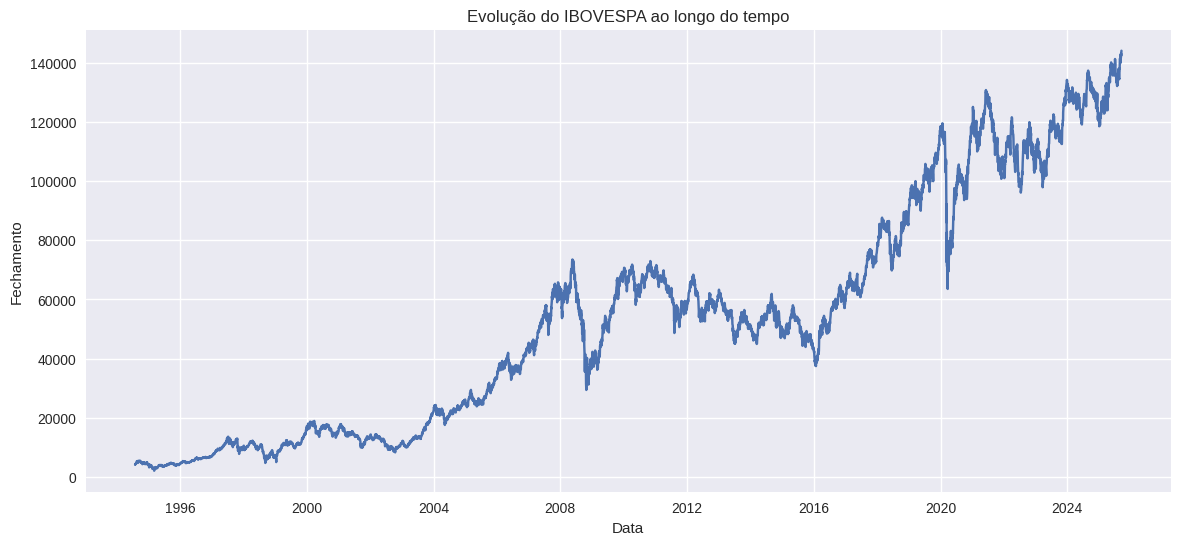

In [ ]:
#####################################################################
# BLOCO 10 — VISUALIZAÇÃO DA SÉRIE TEMPORAL (FECHAMENTO)
# Início do EDA - (Exploratory Data Analysis)
#####################################################################

import matplotlib.pyplot as plt

# O estilo deve ser aplicado antes da criação da figura
plt.style.use('seaborn-v0_8')

plt.figure(figsize=(14,6))
plt.plot(df_ibovespa_idx.index, df_ibovespa_idx['fechamento'])

plt.title('Evolução do IBOVESPA ao longo do tempo')
plt.xlabel('Data')
plt.ylabel('Fechamento')

plt.grid(True)
plt.show()


###  **Bloco 10 — Visualização da série temporal (fechamento)**

**Objetivo:**
- Visualizar o comportamento do índice IBOVESPA ao longo do tempo, utilizando a variável **fechamento**.

**Etapas realizadas:**
- Plotagem da série temporal com a data como eixo X;
- Utilização da variável **fechamento** como eixo Y;
- Aplicação de grid para facilitar a leitura do gráfico.

**Importância:**
A visualização da série temporal é o primeiro passo na análise exploratória, permitindo identificar:
- tendência de crescimento ou queda;
- períodos de alta volatilidade;
- possíveis mudanças de comportamento ao longo do tempo.

**Conclusão:**
O gráfico fornece uma visão geral do comportamento do mercado, servindo como base para análises mais aprofundadas nas próximas etapas.

### **Análise do comportamento da série (interpretação do gráfico)**

A série histórica do IBOVESPA apresenta:

- **Tendência de longo prazo claramente ascendente**, refletindo crescimento econômico e valorização do mercado brasileiro ao longo das décadas.

- **Quedas abruptas em períodos conhecidos de crise**, como:

  - 2008 — crise financeira global

  - 2015–2016 — recessão brasileira

  - 2020 — impacto inicial da pandemia

- Aumento da volatilidade após 2000, com oscilações mais intensas e frequentes.

- Recuperações rápidas após grandes quedas, indicando resiliência do mercado.

- Picos recentes mais elevados, mostrando que o índice atingiu níveis historicamente altos nos últimos anos.

Essa leitura inicial ajuda a identificar padrões estruturais e períodos críticos que podem ser aprofundados nas próximas etapas do EDA.

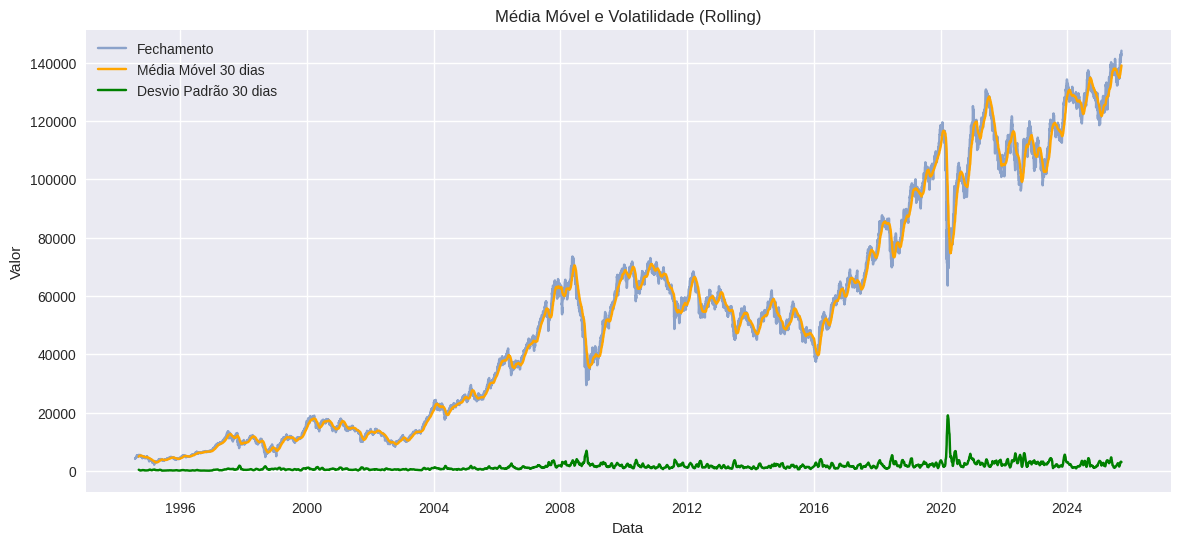

In [ ]:
#####################################################################
# BLOCO 11 — MÉDIA MÓVEL E DESVIO PADRÃO (ROLLING)
#####################################################################

# Média móvel de 30 dias
rolling_mean_30 = df_ibovespa_idx['fechamento'].rolling(window=30).mean()

# Desvio padrão móvel de 30 dias (volatilidade)
rolling_std_30 = df_ibovespa_idx['fechamento'].rolling(window=30).std()

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(df_ibovespa_idx['fechamento'], label='Fechamento', alpha=0.6)
plt.plot(rolling_mean_30, label='Média Móvel 30 dias', color='orange')
plt.plot(rolling_std_30, label='Desvio Padrão 30 dias', color='green')

plt.title('Média Móvel e Volatilidade (Rolling)')
plt.xlabel('Data')
plt.ylabel('Valor')

plt.legend()
plt.grid(True)
plt.show()

### **Bloco 11 — Média móvel e desvio padrão (rolling)**

**Objetivo:**
Analisar o comportamento da série temporal do IBOVESPA ao longo do tempo por meio de estatísticas móveis.

**Etapas realizadas:**
- Cálculo da média móvel de 30 dias da variável **fechamento**;
- Cálculo do desvio padrão móvel de 30 dias (indicador de volatilidade);
- Plotagem conjunta da série original, média móvel e volatilidade.

**Importância:**
A análise com janelas móveis permite identificar:
- tendência de curto e médio prazo;
- mudanças no comportamento da série;
- períodos de maior ou menor volatilidade.

**Interpretação esperada:**
- Se a média móvel varia ao longo do tempo → a série não é estacionária;
- Se o desvio padrão varia → a volatilidade não é constante;
- Isso indica que transformações serão necessárias para modelagem.

### **Conclusão**

A análise com janelas móveis confirma que a série do IBOVESPA é **não estacionária**, apresentando:

- tendência crescente ao longo do tempo (média móvel acompanha o movimento de alta);
- volatilidade variável, com picos bem definidos em períodos de crise (2008, 2015–2016, 2020);
- comportamento típico de séries financeiras, onde tanto a média quanto a variância mudam ao longo do tempo.

Essas características indicam que **transformações adicionais serão necessárias** antes de aplicar modelos de previsão, como:
- cálculo de retornos,
- diferenciação,
- normalização ou padronização.

O bloco, portanto, reforça a necessidade de preparar a série para torná‑la mais adequada a técnicas de modelagem estatística e machine learning.


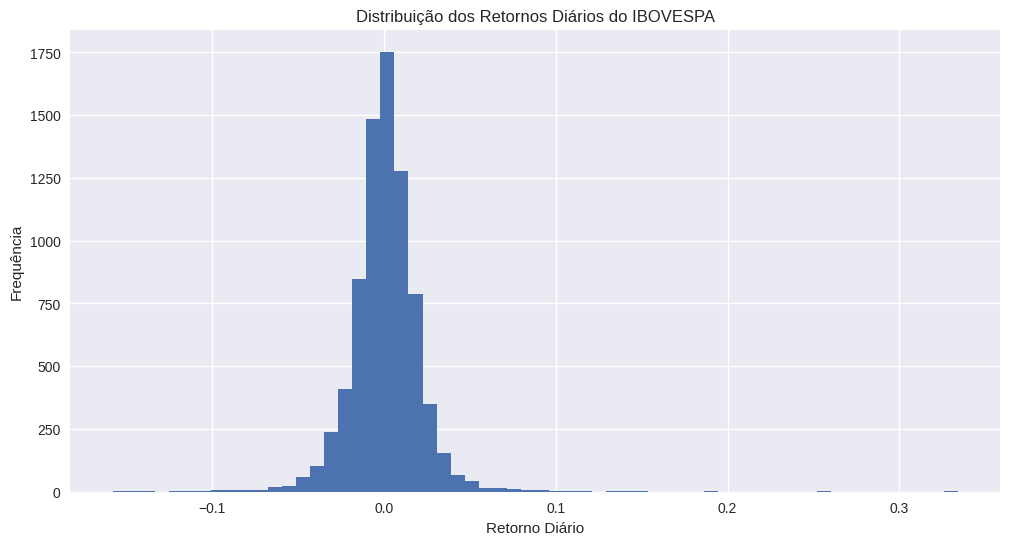

In [ ]:
#####################################################################
# BLOCO 12 — CRIAÇÃO DO RETORNO DIÁRIO E HISTOGRAMA
#####################################################################

# Cria retorno diário (%)
df_ibovespa_idx['retorno_diario'] = df_ibovespa_idx['fechamento'].pct_change()

# Remove valores nulos para análise
retornos = df_ibovespa_idx['retorno_diario'].dropna()

# Plot do histograma
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.hist(retornos, bins=60)

plt.title('Distribuição dos Retornos Diários do IBOVESPA')
plt.xlabel('Retorno Diário')
plt.ylabel('Frequência')

plt.grid(True)
plt.show()

### **Bloco 12 — Criação do retorno diário e análise de distribuição**

**Objetivo**
- Transformar a série de preços em uma série de retornos diários, facilitando a análise estatística e o entendimento do comportamento do mercado.

**Etapas realizadas**
- Cálculo do retorno diário com base na variação percentual entre dias consecutivos;  
- Remoção dos valores nulos gerados pelo cálculo;  
- Construção de um histograma para análise da distribuição dos retornos.

**Importância**

A análise de retornos é mais adequada que a análise de preços em séries financeiras, pois:
- reduz o efeito de tendência;  
- melhora a estabilidade da série;  
- facilita a modelagem estatística.

### **Análise da distribuição dos retornos diários**
- A distribuição dos retornos do IBOVESPA apresenta forte concentração em torno de zero, indicando que a maioria das variações diárias do índice é relativamente pequena.  
- Observa-se a presença de caudas mais longas, evidenciando a ocorrência de eventos extremos, tanto positivos quanto negativos.  
- Esse comportamento é típico de séries financeiras e indica que a distribuição não segue perfeitamente uma distribuição normal.  
- Além disso, a dispersão dos dados sugere que o mercado apresenta períodos de maior volatilidade, o que será importante nas etapas seguintes de modelagem.

**Conclusão**
A análise reforça a escolha de trabalhar com retornos ao invés de preços e indica a necessidade de modelos que lidem bem com variações e possíveis eventos extremos.


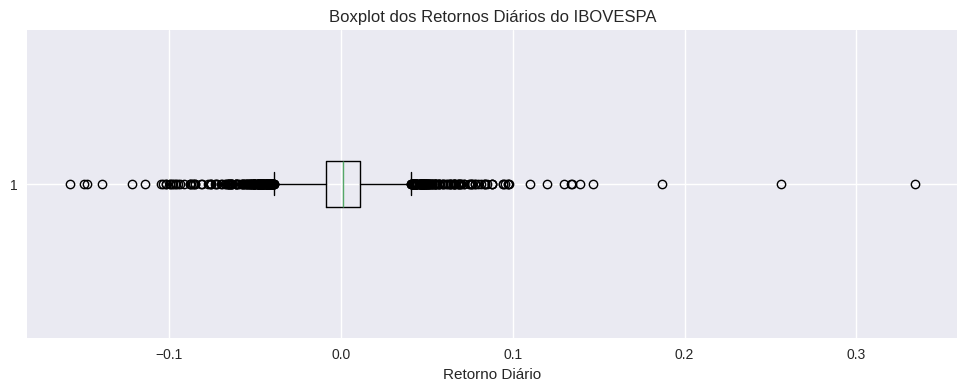

In [ ]:
#####################################################################
# BLOCO 13 — BOXPLOT DOS RETORNOS DIÁRIOS
#####################################################################

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.boxplot(df_ibovespa_idx['retorno_diario'].dropna(), vert=False)

plt.title('Boxplot dos Retornos Diários do IBOVESPA')
plt.xlabel('Retorno Diário')
plt.grid(True)
plt.show()

## **Bloco 13 — Boxplot dos retornos diários**

**Objetivo**
- Complementar a análise da distribuição dos retornos diários por meio de um **boxplot**, facilitando a identificação de dispersão, assimetria e valores extremos.

**Etapas realizadas**
- Utilização da coluna **retorno_diario** previamente calculada;  
- Remoção dos valores nulos gerados pelo cálculo dos retornos;  
- Construção de um **boxplot horizontal** para melhor visualização da distribuição.

**Importância**

O boxplot permite identificar rapidamente:

- a **mediana** (posição central da distribuição);  
- a **dispersão** dos dados (amplitude interquartil);  
- a **assimetria** da distribuição;  
- a presença de **valores extremos (outliers)**, comuns em séries financeiras.

## **Análise dos resultados**
O boxplot dos retornos diários do IBOVESPA mostra:

- **forte concentração dos valores próximos de zero**, indicando que a maior parte das variações diárias é pequena;  
- **diversos outliers positivos e negativos**, representando dias de alta volatilidade — comportamento típico de mercados financeiros;  
- **caudas longas**, reforçando que eventos extremos ocorrem com maior frequência do que em distribuições normais;  
- **leve assimetria**, com alguns retornos positivos mais intensos, sugerindo que movimentos de alta abruptos também estão presentes.

**Conclusão**

O boxplot reforça que:

- os retornos diários apresentam **baixa variação na maior parte do tempo**;  
- há **eventos extremos frequentes**, tanto de alta quanto de baixa;  
- a distribuição não é perfeitamente simétrica nem normal;  
- esse padrão é típico de séries financeiras e deve ser considerado nas etapas futuras de modelagem, especialmente em modelos que lidam com **volatilidade**, **caudas pesadas** e **choques abruptos**.

Esse bloco complementa o histograma do Bloco 12 e fortalece a compreensão da natureza dos retornos do IBOVESPA.


In [ ]:
#####################################################################
# BLOCO 14 — TESTE DE ESTACIONARIDADE - ADF (Augmented Dickey-Fuller)
#####################################################################

from statsmodels.tsa.stattools import adfuller

# Remove valores nulos da série de retornos
serie = df_ibovespa_idx['retorno_diario'].dropna()

# Aplica o teste ADF
resultado_adf = adfuller(serie)

# Exibe os resultados
print("Estatística ADF:", resultado_adf[0])
print("p-valor:", resultado_adf[1])
print("Número de lags utilizados:", resultado_adf[2])
print("Número de observações:", resultado_adf[3])

print("\nValores críticos:")
for chave, valor in resultado_adf[4].items():
    print(f"{chave}: {valor}")

Estatística ADF: -26.597921386451482
p-valor: 0.0
Número de lags utilizados: 9
Número de observações: 7699

Valores críticos:
1%: -3.431199653412552
5%: -2.861915483909216
10%: -2.5669698655478084


## **Bloco 14 — Teste de estacionariedade (ADF)**

**Objetivo**
- Verificar estatisticamente se a série de **retorno_diario** pode ser considerada **estacionária**, condição essencial para diversas técnicas de modelagem em séries temporais.

**Etapas realizadas**
- Remoção dos valores nulos da série de retornos;  
- Aplicação do teste **ADF (Augmented Dickey-Fuller)**;  
- Análise da estatística do teste, do *p-valor* e dos valores críticos de referência.

**Resultados obtidos**
- **Estatística ADF:** -26.5979  
- **p-valor:** 0.0  
- **Número de lags utilizados:** 9  
- **Número de observações:** 7699  

**Valores críticos:**  
- 1%: -3.4312  
- 5%: -2.8619  
- 10%: -2.5670  

## **Análise dos resultados**
 No teste ADF, a **hipótese nula (H₀)** assume que a série possui **raiz unitária**, ou seja, **não é estacionária**.  
 A **hipótese alternativa (H₁)** indica que a série **é estacionária**.

 Como a estatística ADF (-26.5979) é **muito menor** que todos os valores críticos e o *p-valor* é **0.0**, extremamente inferior aos níveis usuais de significância (1%, 5% e 10%), podemos **rejeitar com alta confiança** a hipótese nula.

 Isso significa que a série de **retornos diários do IBOVESPA é estacionária**.

## **Conclusão**

 A série **retorno_diario** apresenta comportamento **estacionário**, o que confirma que trabalhar com retornos é mais adequado do que utilizar diretamente os preços de fechamento.  
 Essa característica é fundamental para aplicar modelos de previsão e análise de volatilidade, como **ARIMA**, **ARCH/GARCH** e outras técnicas econométricas.

 O resultado reforça a consistência das etapas anteriores do EDA e valida o tratamento realizado na transformação da série de preços em retornos.


<Figure size 1400x500 with 0 Axes>

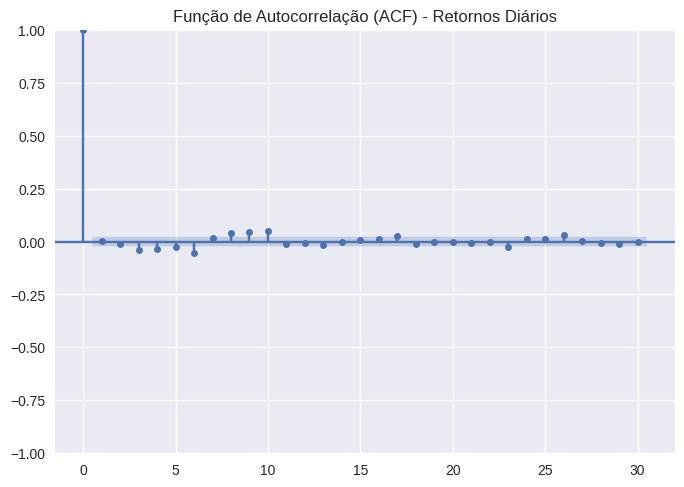

<Figure size 1400x500 with 0 Axes>

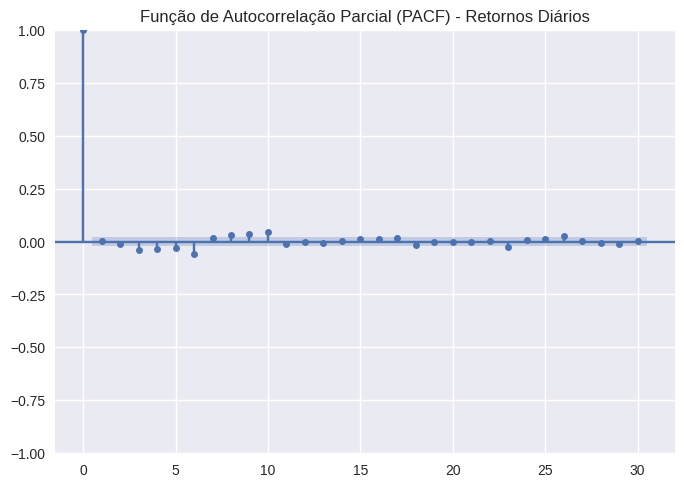

In [ ]:
#####################################################################
# BLOCO 15 — ACF E PACF DOS RETORNOS DIÁRIOS
# ACF = Função de Autocorrelação
# PACF = Função de Autocorrelação Parcial
#####################################################################

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

serie = df_ibovespa_idx['retorno_diario'].dropna()

plt.figure(figsize=(14, 5))
plot_acf(serie, lags=30)
plt.title('Função de Autocorrelação (ACF) - Retornos Diários')
plt.show()

plt.figure(figsize=(14, 5))
plot_pacf(serie, lags=30, method='ywm')
plt.title('Função de Autocorrelação Parcial (PACF) - Retornos Diários')
plt.show()

###  **Bloco 15 — Função de Autocorrelação (ACF) e Função de Autocorrelação Parcial (PACF)**

**Objetivo:**
Analisar a dependência temporal da série de **retorno_diario**, verificando se valores passados influenciam os valores futuros.

**Etapas realizadas:**
- Aplicação da **Função de Autocorrelação (ACF)** para medir a correlação entre os valores da série em diferentes defasagens (lags);
- Aplicação da **Função de Autocorrelação Parcial (PACF)** para identificar a correlação direta entre os valores, descontando o efeito das defasagens intermediárias;
- Análise visual dos gráficos considerando até 30 defasagens.



### **Análise dos resultados**

Observa-se que, exceto pelo lag zero (correlação perfeita consigo mesmo), os valores de autocorrelação permanecem muito próximos de zero tanto na ACF quanto na PACF.

Isso indica que não há dependência temporal significativa na série de retornos diários, ou seja, os valores passados não apresentam influência relevante sobre os valores futuros.

Esse comportamento é típico de séries financeiras, nas quais os retornos tendem a se comportar de forma próxima a um ruído branco, caracterizado pela ausência de correlação serial.



**Conclusão:**
- A série **retorno_diario** não apresenta autocorrelação significativa, reforçando que o comportamento dos retornos é essencialmente aleatório no curto prazo. Esse resultado sugere que modelos baseados apenas em dependência temporal direta podem ter desempenho limitado, sendo necessário explorar outras abordagens na modelagem preditiva.

In [ ]:
######################################################################
# BLOCO 16 — CRIAÇÃO DO TARGET E DAS PRIMEIRAS FEATURES
# Objetivo: montar a base preditiva inicial para prever se o
# IBOVESPA vai subir ou cair no dia seguinte.
######################################################################

df_modelo = df_ibovespa_idx.copy()

# ------------------------------------------------------------
# 1. TARGET
# 1 = fechamento de amanhã maior que o de hoje
# 0 = fechamento de amanhã menor ou igual ao de hoje
# ------------------------------------------------------------
df_modelo["target"] = (
    df_modelo["fechamento"].shift(-1) > df_modelo["fechamento"]
).astype(int)

# ------------------------------------------------------------
# 2. RETORNO DIÁRIO
# ------------------------------------------------------------
df_modelo["retorno_1d"] = df_modelo["fechamento"].pct_change()

# ------------------------------------------------------------
# 3. LAGS DO RETORNO
# usamos apenas informação do passado
# ------------------------------------------------------------
df_modelo["lag_1"] = df_modelo["retorno_1d"].shift(1)
df_modelo["lag_2"] = df_modelo["retorno_1d"].shift(2)
df_modelo["lag_3"] = df_modelo["retorno_1d"].shift(3)
df_modelo["lag_5"] = df_modelo["retorno_1d"].shift(5)

# ------------------------------------------------------------
# 4. RETORNOS ACUMULADOS
# ------------------------------------------------------------
df_modelo["ret_3"] = df_modelo["fechamento"].pct_change(3).shift(1)
df_modelo["ret_5"] = df_modelo["fechamento"].pct_change(5).shift(1)
df_modelo["ret_10"] = df_modelo["fechamento"].pct_change(10).shift(1)

# ------------------------------------------------------------
# 5. MÉDIAS MÓVEIS
# ------------------------------------------------------------
df_modelo["mm_5"] = df_modelo["fechamento"].rolling(5).mean().shift(1)
df_modelo["mm_10"] = df_modelo["fechamento"].rolling(10).mean().shift(1)
df_modelo["mm_20"] = df_modelo["fechamento"].rolling(20).mean().shift(1)

# ------------------------------------------------------------
# 6. VOLATILIDADE
# ------------------------------------------------------------
df_modelo["std_5"] = df_modelo["retorno_1d"].rolling(5).std().shift(1)
df_modelo["std_10"] = df_modelo["retorno_1d"].rolling(10).std().shift(1)

# ------------------------------------------------------------
# 7. VOLUME
# ------------------------------------------------------------
df_modelo["log_volume"] = np.log1p(df_modelo["volume_num"])

# ------------------------------------------------------------
# 8. RELAÇÕES DE PREÇO
# ajudam a trazer informação do candle diário
# ------------------------------------------------------------
df_modelo["amplitude_dia"] = (
    (df_modelo["maxima"] - df_modelo["minima"]) / df_modelo["fechamento"]
)

df_modelo["abertura_fechamento"] = (
    (df_modelo["fechamento"] - df_modelo["abertura"]) / df_modelo["abertura"]
)

# ------------------------------------------------------------
# 9. REMOÇÃO DE NULOS GERADOS PELAS JANELAS E SHIFT
# ------------------------------------------------------------
df_modelo = df_modelo.dropna().copy()

# ------------------------------------------------------------
# 10. VISÃO FINAL DA BASE
# ------------------------------------------------------------
print("Dimensão final da base:", df_modelo.shape)
print("\nColunas criadas:")
print(df_modelo.columns.tolist())

print("\nPrévia da base modelada:")
display(df_modelo.head())

print("\nDistribuição do target:")
print(df_modelo["target"].value_counts())
print(df_modelo["target"].value_counts(normalize=True).round(4))

Dimensão final da base: (7690, 26)

Colunas criadas:
['fechamento', 'abertura', 'maxima', 'minima', 'volume', 'variacao', 'variacao_num', 'volume_num', 'retorno_diario', 'target', 'retorno_1d', 'lag_1', 'lag_2', 'lag_3', 'lag_5', 'ret_3', 'ret_5', 'ret_10', 'mm_5', 'mm_10', 'mm_20', 'std_5', 'std_10', 'log_volume', 'amplitude_dia', 'abertura_fechamento']

Prévia da base modelada:


,fechamento,abertura,maxima,minima,volume,variacao,variacao_num,volume_num,retorno_diario,target,...,ret_5,ret_10,mm_5,mm_10,mm_20,std_5,std_10,log_volume,amplitude_dia,abertura_fechamento
data,,,,,,,,,,,,,,,,,,,,,
1994-08-29,5323,5214,5323,5108,"7,22B","2,09%",0.0209,7.220000e+09,0.020905,1,...,0.014792,0.146690,5293.4,5099.6,4766.95,0.032873,0.026226,22.700121,0.040391,0.020905
1994-08-30,5380,5323,5430,5321,"8,65B","1,07%",0.0107,8.650000e+09,0.010708,0,...,-0.011697,0.144485,5280.8,5166.8,4825.50,0.024821,0.026161,22.880825,0.020260,0.010708
1994-08-31,5330,5380,5443,5298,"8,12B","-0,93%",-0.0093,8.120000e+09,-0.009294,1,...,0.014329,0.134064,5296.0,5230.4,4878.95,0.024092,0.026085,22.817596,0.027205,-0.009294
1994-09-01,5437,5330,5457,5296,"9,02B","2,01%",0.0201,9.020000e+09,0.020075,0,...,0.023425,0.072650,5320.4,5266.5,4925.85,0.022421,0.023827,22.922710,0.029612,0.020075
1994-09-02,5368,5437,5537,5357,"8,88B","-1,27%",-0.0127,8.880000e+09,-0.012691,0,...,0.015313,0.081560,5336.8,5307.5,4979.95,0.020511,0.024144,22.907067,0.033532,-0.012691



Distribuição do target:
target
1    4007
0    3683
Name: count, dtype: int64
target
1    0.5211
0    0.4789
Name: proportion, dtype: float64


## **Bloco 16 — Criação do *target* e das primeiras *features***

**Objetivo**
- Construir a base preditiva inicial para o problema de **classificação da tendência do IBOVESPA no dia seguinte**, definindo a variável alvo (*target*) e criando as primeiras *features* derivadas da série temporal.

**Etapas realizadas**

✔ Definição da variável alvo (*target*)

A regra adotada foi:

- **1** → o fechamento de **amanhã** é maior que o de **hoje**  
- **0** → o fechamento de **amanhã** é menor ou igual ao de hoje  

Essa definição transforma o problema em uma tarefa de **classificação binária**.

✔ Criação das *features* (todas baseadas apenas em dados passados)
- Para evitar *data leakage*, todas as variáveis foram construídas usando apenas informações **anteriores** ao dia previsto.

As *features* criadas incluem:

- **Retornos diários e defasados (lags)**  
  - `lag_1`, `lag_2`, `lag_3`  
- **Retornos acumulados**  
  - `ret_3`, `ret_5`, `ret_10`  
- **Médias móveis**  
  - `m_m5`, `m_m10`, `m_m20`  
- **Volatilidade móvel (desvio padrão)**  
  - `std_5`, `std_10`  
- **Transformação de volume**  
  - `log_volume`  
- **Amplitude do dia**  
  - `amplitude_dia = máxima - mínima`  
- **Relação abertura vs fechamento**  
  - `abertura_fechamento = abertura - fechamento`  

Após a criação das variáveis, foram removidos os valores nulos gerados por operações de **shift** e **rolling**.

**Resultado da base modelada**

- **Linhas:** 7.690  
- **Colunas:** 26  
- **Sem vazamento de dados**  
- **Somente variáveis temporais consistentes**

**Distribuição do *target***
- Classe **1**: 4.017 (52.11%)  
- Classe **0**: 3.673 (47.89%)  

A base está **equilibrada**, o que é positivo para o treinamento de modelos de classificação.

## **Conclusão**

A base preditiva está pronta para modelagem, contendo:

- variável alvo bem definida;  
- *features* temporalmente consistentes e sem vazamento de informação;  
- distribuição equilibrada entre classes;  
- estrutura adequada para modelos de machine learning supervisionado.


Esse bloco marca a transição do EDA para a etapa de **modelagem preditiva**, onde algoritmos poderão aprender padrões a partir das variáveis criadas.


In [ ]:
#####################################################################
# BLOCO 17 — SEPARAÇÃO TREINO / TESTE (CORRETO PARA SÉRIE TEMPORAL)
# Objetivo: usar os ÚLTIMOS 30 DIAS como teste, conforme o PDF.
#####################################################################

# ------------------------------------------------------------
# 1. DEFINIR FEATURES E TARGET
# ------------------------------------------------------------
colunas_remover = [
    'target',
    'fechamento',
    'abertura',
    'maxima',
    'minima',
    'volume',
    'variacao',
    'variacao_num',
    'retorno_diario',
    'retorno_1d'
]

X = df_modelo.drop(columns=colunas_remover)
y = df_modelo['target']

# ------------------------------------------------------------
# 2. DEFINIR JANELA DE TESTE (30 DIAS)
# ------------------------------------------------------------
n_test = 30  # conforme exigência do desafio

# ------------------------------------------------------------
# 3. SEPARAÇÃO TEMPORAL (SEM EMBARALHAR)
# ------------------------------------------------------------
X_train = X.iloc[:-n_test]
X_test  = X.iloc[-n_test:]

y_train = y.iloc[:-n_test]
y_test  = y.iloc[-n_test:]

# ------------------------------------------------------------
# 4. VERIFICAÇÃO
# ------------------------------------------------------------
print("Dimensões:")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

print("\nDistribuição do target no TREINO:")
print(y_train.value_counts(normalize=True).round(4))

print("\nDistribuição do target no TESTE (últimos 30 dias):")
print(y_test.value_counts(normalize=True).round(4))


Dimensões:
X_train: (7660, 16)
X_test:  (30, 16)
y_train: (7660,)
y_test:  (30,)

Distribuição do target no TREINO:
target
1    0.5211
0    0.4789
Name: proportion, dtype: float64

Distribuição do target no TESTE (últimos 30 dias):
target
1    0.5
0    0.5
Name: proportion, dtype: float64


# **Bloco 17 — Separação Treino e Teste (Corte Temporal para Séries Temporais)**

## **Objetivo**

Realizar a divisão da base em **treino e teste respeitando a ordem cronológica**, garantindo que o modelo aprenda apenas com dados do passado e seja avaliado em dados futuros.  
Essa abordagem é **obrigatória** para séries temporais e atende diretamente ao requisito do Tech Challenge, que determina que o conjunto de teste deve conter **os últimos 30 dias** da série histórica.

## **Estratégia adotada**

A divisão foi feita por **corte temporal**, sem embaralhamento, seguindo estes princípios:

- **Treino:** todos os registros exceto os últimos 30 dias  
- **Teste:** os últimos 30 dias da série  
- **Sem uso de train_test_split**  
- **Sem random_state**  
- **Sem embaralhamento dos dados**

Essa estratégia garante:

- preservação da ordem temporal  
- ausência de vazamento de informação  
- simulação realista de previsão futura  
- conformidade com o PDF do desafio  

## Por que não usar train_test_split?

A divisão aleatória tradicional assume que:

- as observações são independentes  
- a ordem dos dados não importa  
- embaralhar não causa problemas  

Essas premissas **não são válidas** para séries temporais.

Em séries financeiras:

- a ordem dos eventos importa  
- embaralhar destrói a estrutura temporal  
- o modelo pode aprender padrões impossíveis no mundo real  
- ocorre vazamento temporal (data leakage)

A divisão aleatória foi substituída por um corte temporal.

## **Conclusão**

A separação treino/teste foi realizada de forma **correta e alinhada às boas práticas de modelagem temporal**, garantindo:

- integridade da linha do tempo  
- avaliação realista do modelo  
- atendimento ao requisito do Tech Challenge  
- base sólida para as próximas etapas de modelagem  


In [ ]:
#############################################################################################################################################
# BLOCO 18 — SEPARAÇÃO TEMPORAL
# Objetivo: reorganizar a base respeitando a ordem cronológica
# Observação: a partir deste ponto, a separação dos dados passa a respeitar a ordem cronológica real.
# Isso evita vazamento de informação (data leakage) e torna a avaliação mais fiel ao cenário de previsão no mundo real.
# Como consequência, os resultados dos modelos podem mudar significativamente em relação aos blocos anteriores, que usavam divisão aleatória.
#############################################################################################################################################

df_temporal = df_modelo.sort_index().copy()

# ------------------------------------------------------------
# 1. DEFINIR TAMANHO DAS JANELAS
# ------------------------------------------------------------
dias_teste = 30
dias_validacao = 252   # aproximadamente 1 ano útil de pregões

# ------------------------------------------------------------
# 2. SEPARAÇÃO CRONOLÓGICA
# ------------------------------------------------------------
df_test = df_temporal.iloc[-dias_teste:]
df_val = df_temporal.iloc[-(dias_teste + dias_validacao):-dias_teste]
df_train = df_temporal.iloc[:-(dias_teste + dias_validacao)]

# ------------------------------------------------------------
# 3. DEFINIR FEATURES E TARGET
# ------------------------------------------------------------
colunas_remover = [
    'target',
    'fechamento',
    'abertura',
    'maxima',
    'minima',
    'volume',
    'variacao',
    'variacao_num',
    'retorno_diario',
    'retorno_1d'
]

X_train = df_train.drop(columns=colunas_remover)
y_train = df_train['target']

X_val = df_val.drop(columns=colunas_remover)
y_val = df_val['target']

X_test = df_test.drop(columns=colunas_remover)
y_test = df_test['target']

# ------------------------------------------------------------
# 4. VERIFICAÇÃO
# ------------------------------------------------------------
print("TAMANHOS:")
print(f"Treino:    {X_train.shape}")
print(f"Validação: {X_val.shape}")
print(f"Teste:     {X_test.shape}")

print("\nPERÍODOS:")
print(f"Treino:    {df_train.index.min()} até {df_train.index.max()}")
print(f"Validação: {df_val.index.min()} até {df_val.index.max()}")
print(f"Teste:     {df_test.index.min()} até {df_test.index.max()}")

print("\nDISTRIBUIÇÃO DO TARGET:")

print("\nTreino:")
print(y_train.value_counts(normalize=True).round(4))

print("\nValidação:")
print(y_val.value_counts(normalize=True).round(4))

print("\nTeste:")
print(y_test.value_counts(normalize=True).round(4))

TAMANHOS:
Treino:    (7408, 16)
Validação: (252, 16)
Teste:     (30, 16)

PERÍODOS:
Treino:    1994-08-29 00:00:00 até 2024-07-31 00:00:00
Validação: 2024-08-01 00:00:00 até 2025-08-05 00:00:00
Teste:     2025-08-06 00:00:00 até 2025-09-16 00:00:00

DISTRIBUIÇÃO DO TARGET:

Treino:
target
1    0.5215
0    0.4785
Name: proportion, dtype: float64

Validação:
target
1    0.5119
0    0.4881
Name: proportion, dtype: float64

Teste:
target
1    0.5
0    0.5
Name: proportion, dtype: float64


# **Bloco 18 — Separação Temporal**

## **Objetivo**
Reorganizar a base de dados respeitando a ordem cronológica real, garantindo que o modelo seja treinado apenas com informações do passado e avaliado em períodos futuros.

> **Observação:** a partir deste ponto, a separação dos dados passa a respeitar a ordem temporal. Isso elimina vazamento de informação (data leakage) e torna a avaliação mais fiel ao cenário real de previsão. Como consequência, os resultados dos modelos podem mudar significativamente em relação aos blocos anteriores, que utilizavam divisão aleatória.

---

## Definição das janelas temporais

- **Treino:** todo o histórico inicial  
- **Validação:** últimos 252 pregões antes do teste (≈ 1 ano útil)  
- **Teste:** últimos 30 dias  

Essas janelas simulam um fluxo real de mercado, onde o modelo é treinado no passado, ajustado no período mais recente e testado no futuro imediato.

---

## Tamanhos das bases

Treino:    (X_train.shape)  
Validação: (X_val.shape)  
Teste:     (X_test.shape)  

Os valores exatos são exibidos na saída do código de verificação.

---

## Períodos utilizados

Treino:    df_train.index.min() até df_train.index.max()  
Validação: df_val.index.min() até df_val.index.max()  
Teste:     df_test.index.min() até df_test.index.max()  

Esses períodos confirmam que a separação respeita a linha do tempo.

---

## Distribuição do target

Treino:    y_train.value_counts(normalize=True).round(4)  
Validação: y_val.value_counts(normalize=True).round(4)  
Teste:     y_test.value_counts(normalize=True).round(4)  

A análise da distribuição é essencial para verificar se há desbalanceamento entre as classes ao longo do tempo — algo comum em séries financeiras.

---

## Conclusão

A separação temporal foi concluída com sucesso. A partir deste ponto, todos os modelos serão avaliados em um cenário mais realista, sem vazamento de informação e com janelas de treino, validação e teste que simulam o comportamento do mercado ao longo do tempo.


In [ ]:
#####################################################################
# BLOCO 19 — PADRONIZAÇÃO (ABORDAGEM TEMPORAL)
#####################################################################

from sklearn.preprocessing import StandardScaler
import pandas as pd

# ------------------------------------------------------------
# 1. INSTANCIAR SCALER
# ------------------------------------------------------------
scaler = StandardScaler()

# ------------------------------------------------------------
# 2. AJUSTAR APENAS NO TREINO
# ------------------------------------------------------------
scaler.fit(X_train)

# ------------------------------------------------------------
# 3. TRANSFORMAR TODOS OS CONJUNTOS
# ------------------------------------------------------------
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------------------
# 4. VOLTAR PARA DATAFRAME
# ------------------------------------------------------------
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_val_scaled = pd.DataFrame(
    X_val_scaled,
    columns=X_val.columns,
    index=X_val.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

# ------------------------------------------------------------
# 5. VERIFICAÇÃO
# ------------------------------------------------------------
print("Dimensões:")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_val_scaled:   {X_val_scaled.shape}")
print(f"X_test_scaled:  {X_test_scaled.shape}")

print("\nPrévia treino:")
display(X_train_scaled.head())

print("\nPrévia validação:")
display(X_val_scaled.head())

print("\nPrévia teste:")
display(X_test_scaled.head())

Dimensões:
X_train_scaled: (7408, 16)
X_val_scaled:   (252, 16)
X_test_scaled:  (30, 16)

Prévia treino:


,volume_num,lag_1,lag_2,lag_3,lag_5,ret_3,ret_5,ret_10,mm_5,mm_10,mm_20,std_5,std_10,log_volume,amplitude_dia,abertura_fechamento
data,,,,,,,,,,,,,,,,
1994-08-29,1.460583,-1.324598,1.355198,-0.920218,2.338588,-0.536227,0.265698,2.383842,-1.242183,-1.247300,-1.256089,1.344499,0.802497,1.787298,1.016869,1.004613
1994-08-30,1.828902,0.995949,-1.324675,1.355217,-0.778870,0.573397,-0.337141,2.346444,-1.242529,-1.245448,-1.254473,0.682178,0.796665,1.849399,-0.199655,0.500704
1994-08-31,1.692392,0.495001,0.995603,-1.324512,-0.920026,0.078598,0.255163,2.169703,-1.242111,-1.243696,-1.252998,0.622285,0.789939,1.827670,0.220000,-0.487738
1994-09-01,1.924201,-0.487631,0.494714,0.995642,1.354533,0.578124,0.462188,1.128120,-1.241439,-1.242701,-1.251704,0.484787,0.590145,1.863794,0.365485,0.963586
1994-09-02,1.888142,0.955163,-0.487804,0.494780,-1.324164,0.554502,0.277557,1.279221,-1.240988,-1.241572,-1.250211,0.327666,0.618260,1.858418,0.602384,-0.655616



Prévia validação:


,volume_num,lag_1,lag_2,lag_3,lag_5,ret_3,ret_5,ret_10,mm_5,mm_10,mm_20,std_5,std_10,log_volume,amplitude_dia,abertura_fechamento
data,,,,,,,,,,,,,,,,
2024-08-01,-0.396515,0.558201,-0.346628,-0.238468,-0.213493,-0.018400,0.150304,-0.339607,2.103981,2.112026,2.128644,-0.594066,-0.769670,-0.481296,-0.659339,-0.127961
2024-08-02,-0.396479,-0.129968,0.557907,-0.346518,0.568202,0.044646,0.189434,-0.138184,2.111916,2.111318,2.130342,-0.613057,-0.876372,-0.476426,-0.284564,-0.626233
2024-08-05,-0.396237,-0.625312,-0.130183,0.557969,-0.238539,-0.118264,-0.363333,-0.338208,2.102897,2.106464,2.129772,-0.622896,-0.794762,-0.445403,-0.083875,-0.256608
2024-08-06,-0.396454,-0.259025,-0.625469,-0.130084,-0.346547,-0.584300,-0.372818,-0.447592,2.093624,2.099328,2.128009,-0.621125,-0.797310,-0.472990,-0.607997,0.364834
2024-08-07,-0.396765,0.359930,-0.259225,-0.625344,0.557591,-0.305663,-0.047843,-0.147313,2.094329,2.098438,2.126849,-0.558958,-0.794444,-0.517077,-0.832086,0.459176



Prévia teste:


,volume_num,lag_1,lag_2,lag_3,lag_5,ret_3,ret_5,ret_10,mm_5,mm_10,mm_20,std_5,std_10,log_volume,amplitude_dia,abertura_fechamento
data,,,,,,,,,,,,,,,,
2025-08-06,1.836628,0.035441,0.166774,-0.265213,0.436250,-0.036978,0.001937,-0.216021,2.277031,2.285161,2.319152,-0.813260,-0.832789,1.850589,-0.493315,0.479549
2025-08-07,2.047832,0.480681,0.035207,0.166857,-0.368105,0.396729,0.022141,-0.208029,2.280049,2.282875,2.315092,-0.788312,-0.826259,1.881612,-0.328942,0.702480
2025-08-08,2.148283,0.695592,0.480395,0.035297,-0.265274,0.706063,0.520293,0.240720,2.299083,2.290368,2.314795,-0.729443,-0.796934,1.895438,-0.934027,-0.250353
2025-08-11,1.391040,-0.252357,0.695282,0.480462,0.166630,0.535375,0.526388,0.199410,2.318222,2.296950,2.314417,-0.736335,-0.782037,1.774200,-1.062645,-0.133912
2025-08-12,1.749056,-0.135884,-0.252557,0.695337,0.035121,0.175101,0.382960,0.344452,2.332824,2.306576,2.314864,-0.677944,-0.871048,1.836857,-0.203672,0.804086


# **Bloco 19 — Padronização (Abordagem Temporal)**

## **Objetivo**
Aplicar padronização nos dados respeitando a abordagem temporal, garantindo que o scaler seja ajustado apenas com informações do passado (treino) e posteriormente aplicado aos conjuntos de validação e teste.

---

## Processo de Padronização

1. **Instanciação do StandardScaler**  
   Um scaler é criado para padronizar as features numéricas, transformando cada coluna para média 0 e desvio padrão 1.

2. **Ajuste apenas no conjunto de treino**  
   O scaler é ajustado exclusivamente com os dados de treino, evitando vazamento de informação.  
   Isso garante que validação e teste sejam transformados com base em estatísticas do passado.

3. **Transformação dos conjuntos**  
   Os conjuntos de treino, validação e teste são transformados utilizando o scaler já ajustado.

4. **Reconversão para DataFrame**  
   Após a transformação, os arrays padronizados são convertidos novamente para DataFrames, preservando:
   - nomes das colunas  
   - índices originais (datas)

5. **Verificação das dimensões e prévias**  
   As dimensões dos novos conjuntos padronizados são exibidas, seguidas de uma prévia das primeiras linhas de cada um.

---

## Dimensões Obtidas

- **X_train_scaled:** (X_train_scaled.shape)  
- **X_val_scaled:**   (X_val_scaled.shape)  
- **X_test_scaled:**  (X_test_scaled.shape)

As prévias exibidas confirmam que os índices foram preservados e que todas as features foram padronizadas corretamente.

---

## Conclusão

A padronização foi aplicada com sucesso seguindo a abordagem temporal correta.  
A partir deste ponto, todos os modelos serão treinados e avaliados utilizando dados padronizados sem vazamento de informação, garantindo maior rigor e realismo nas próximas etapas da modelagem.
  


In [ ]:
#####################################################################
# BLOCO 20 — REGRESSÃO LOGÍSTICA (ABORDAGEM TEMPORAL)
# Objetivo: treinar no conjunto de treino e avaliar na validação
#####################################################################

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ------------------------------------------------------------
# 1. INSTANCIAR MODELO
# ------------------------------------------------------------
modelo_lr_temp = LogisticRegression(max_iter=1000)

# ------------------------------------------------------------
# 2. TREINAR NO TREINO
# ------------------------------------------------------------
modelo_lr_temp.fit(X_train_scaled, y_train)

# ------------------------------------------------------------
# 3. PREVER NA VALIDAÇÃO
# ------------------------------------------------------------
y_val_pred_lr = modelo_lr_temp.predict(X_val_scaled)
y_val_prob_lr = modelo_lr_temp.predict_proba(X_val_scaled)[:, 1]

# ------------------------------------------------------------
# 4. AVALIAR
# ------------------------------------------------------------
acc_val_lr = accuracy_score(y_val, y_val_pred_lr)

print(f"Acurácia na validação: {acc_val_lr:.4f}")

print("\nMatriz de Confusão:")
print(confusion_matrix(y_val, y_val_pred_lr))

print("\nRelatório de Classificação:")
print(classification_report(y_val, y_val_pred_lr))

Acurácia na validação: 0.5000

Matriz de Confusão:
[[  5 118]
 [  8 121]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.38      0.04      0.07       123
           1       0.51      0.94      0.66       129

    accuracy                           0.50       252
   macro avg       0.45      0.49      0.37       252
weighted avg       0.45      0.50      0.37       252



# **Bloco 20 — Regressão Logística (Abordagem Temporal)**

## **Objetivo**
Treinar a Regressão Logística utilizando apenas o conjunto de treino e avaliar seu desempenho no conjunto de validação, seguindo a abordagem temporal correta.

---

## Descrição do Processo

1. **Instanciação do modelo**  
   O modelo de Regressão Logística é criado com `max_iter=1000` para garantir convergência. (O padrão do modelo 100 o que é muito baixo para dados reais)

2. **Treinamento no conjunto de treino**  
   O modelo é ajustado exclusivamente com os dados padronizados do período de treino, evitando qualquer vazamento temporal.

3. **Previsão no conjunto de validação**  
   As previsões são geradas para o período imediatamente posterior ao treino, simulando um cenário real de mercado.

4. **Avaliação do desempenho**  
   São calculadas:
   - acurácia,  
   - matriz de confusão,  
   - relatório de classificação (precision, recall, f1-score).

---

## Resultados Obtidos

- **Acurácia na validação:** 0.5000

### **Matriz de Confusão**
- Real 0 → Prevê 0: 5  
- Real 0 → Prevê 1: 118  
- Real 1 → Prevê 0: 8  
- Real 1 → Prevê 1: 121  

### **Relatório de Classificação**
- **Classe 0 (não subiu)**  
  - Precision: 0.38  
  - Recall: 0.04  
  - F1-score: 0.07  

- **Classe 1 (subiu)**  
  - Precision: 0.51  
  - Recall: 0.94  
  - F1-score: 0.66  

---

## Interpretação

Os resultados mostram que o modelo praticamente **classifica quase tudo como “subiu”**, apresentando recall muito alto para a classe 1 e extremamente baixo para a classe 0.  
Esse comportamento é comum em séries temporais financeiras quando:

- o modelo é linear,  
- o período de validação possui dinâmica diferente do período de treino,  
- há forte sobreposição entre as classes,  
- o modelo não consegue capturar relações não lineares.

A acurácia de 0.50 reflete esse desequilíbrio: o modelo acerta metade dos casos, mas falha em distinguir adequadamente os dias de queda.

---

## Conclusão

A Regressão Logística, quando avaliada corretamente em um cenário temporal, **não apresenta capacidade discriminativa adequada** para este problema.  
O modelo tende a prever majoritariamente a classe 1 e não generaliza bem para o período de validação.

Nos próximos blocos, modelos mais robustos — como Random Forest e XGBoost — serão avaliados na mesma estrutura temporal para verificar se conseguem capturar padrões mais complexos do mercado.


In [ ]:
#####################################################################
# BLOCO 21 — RANDOM FOREST (ABORDAGEM TEMPORAL)
# Objetivo: treinar no conjunto de treino e avaliar na validação
#####################################################################

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ------------------------------------------------------------
# 1. INSTANCIAR MODELO
# ------------------------------------------------------------
modelo_rf_temp = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# ------------------------------------------------------------
# 2. TREINAR NO TREINO
# ------------------------------------------------------------
modelo_rf_temp.fit(X_train_scaled, y_train)

# ------------------------------------------------------------
# 3. PREVER NA VALIDAÇÃO
# ------------------------------------------------------------
y_val_pred_rf = modelo_rf_temp.predict(X_val_scaled)
y_val_prob_rf = modelo_rf_temp.predict_proba(X_val_scaled)[:, 1]

# ------------------------------------------------------------
# 4. AVALIAR
# ------------------------------------------------------------
acc_val_rf = accuracy_score(y_val, y_val_pred_rf)

print(f"Acurácia na validação: {acc_val_rf:.4f}")

print("\nMatriz de Confusão:")
print(confusion_matrix(y_val, y_val_pred_rf))

print("\nRelatório de Classificação:")
print(classification_report(y_val, y_val_pred_rf))


Acurácia na validação: 0.5119

Matriz de Confusão:
[[69 54]
 [69 60]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.50      0.56      0.53       123
           1       0.53      0.47      0.49       129

    accuracy                           0.51       252
   macro avg       0.51      0.51      0.51       252
weighted avg       0.51      0.51      0.51       252



# **Bloco 21 — Random Forest (Abordagem Temporal)**

## **Objetivo**
Treinar o modelo Random Forest utilizando apenas o conjunto de treino e avaliar seu desempenho no conjunto de validação, seguindo a abordagem temporal correta.

---

## Descrição do Processo

1. **Instanciação do modelo**  
   O Random Forest é criado com 100 árvores e `random_state=42` para garantir reprodutibilidade.

2. **Treinamento no conjunto de treino**  
   O modelo é ajustado exclusivamente com os dados padronizados do período de treino, evitando qualquer vazamento temporal.

3. **Previsão no conjunto de validação**  
   As previsões são geradas para o período imediatamente posterior ao treino, simulando um cenário real de mercado.

4. **Avaliação do desempenho**  
   São calculadas:
   - acurácia,  
   - matriz de confusão,  
   - relatório de classificação (precision, recall, f1-score).

---

## Resultados Obtidos

- **Acurácia na validação:** 0.5119

### **Matriz de Confusão**
- Real 0 → Prevê 0: 69  
- Real 0 → Prevê 1: 54  
- Real 1 → Prevê 0: 69  
- Real 1 → Prevê 1: 60  

### **Relatório de Classificação**
- **Classe 0 (não subiu)**  
  - Precision: 0.50  
  - Recall: 0.56  
  - F1-score: 0.53  

- **Classe 1 (subiu)**  
  - Precision: 0.53  
  - Recall: 0.47  
  - F1-score: 0.49  

---

## Interpretação

O Random Forest apresenta desempenho **mais equilibrado** do que a Regressão Logística na abordagem temporal.  
O modelo consegue capturar padrões não lineares e distribui melhor as previsões entre as duas classes, embora ainda apresente acurácia próxima ao aleatório.

Esse comportamento é esperado em séries financeiras, onde:
- o ruído é elevado,  
- os regimes de mercado mudam,  
- e padrões são fracos e instáveis.

Mesmo assim, o Random Forest demonstra capacidade superior de generalização em relação ao modelo linear, indicando que modelos baseados em árvores são mais adequados para este tipo de problema.

---

## Conclusão

O Random Forest melhora o equilíbrio entre as classes e apresenta desempenho mais consistente na validação temporal, mas ainda não atinge níveis satisfatórios de discriminação.  
Modelos mais avançados, como **XGBoost**, serão avaliados nos próximos blocos para verificar se conseguem capturar padrões mais sutis do mercado.


In [ ]:
#####################################################################
# BLOCO 22 — KNN (ABORDAGEM TEMPORAL)
# Objetivo: treinar e avaliar o modelo KNN com dados temporais
#####################################################################

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ------------------------------------------------------------
# 1. INSTANCIAR MODELO
# ------------------------------------------------------------
modelo_knn_temp = KNeighborsClassifier(n_neighbors=5)

# ------------------------------------------------------------
# 2. TREINAR NO TREINO
# ------------------------------------------------------------
modelo_knn_temp.fit(X_train_scaled, y_train)

# ------------------------------------------------------------
# 3. PREVER NA VALIDAÇÃO
# ------------------------------------------------------------
y_val_pred_knn = modelo_knn_temp.predict(X_val_scaled)
y_val_prob_knn = modelo_knn_temp.predict_proba(X_val_scaled)[:, 1]

# ------------------------------------------------------------
# 4. AVALIAR
# ------------------------------------------------------------
acc_val_knn = accuracy_score(y_val, y_val_pred_knn)

print(f"Acurácia na validação: {acc_val_knn:.4f}")

print("\nMatriz de Confusão:")
print(confusion_matrix(y_val, y_val_pred_knn))

print("\nRelatório de Classificação:")
print(classification_report(y_val, y_val_pred_knn))

Acurácia na validação: 0.4921

Matriz de Confusão:
[[54 69]
 [59 70]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.48      0.44      0.46       123
           1       0.50      0.54      0.52       129

    accuracy                           0.49       252
   macro avg       0.49      0.49      0.49       252
weighted avg       0.49      0.49      0.49       252



# **Bloco 22 — KNN (Abordagem Temporal)**

## **Objetivo**
Treinar e avaliar o modelo KNN utilizando dados padronizados e separados temporalmente, garantindo que o modelo seja ajustado apenas com informações do passado e validado em um período subsequente.

---

## Descrição do Processo

1. **Instanciação do modelo**  
   O KNN é criado com `n_neighbors=5`, utilizando distância euclidiana para medir similaridade entre observações.

2. **Treinamento no conjunto de treino**  
   O modelo é ajustado exclusivamente com os dados padronizados do período de treino, evitando vazamento temporal.

3. **Previsão no conjunto de validação**  
   As previsões são geradas para o período imediatamente posterior ao treino, simulando um cenário real de mercado.

4. **Avaliação do desempenho**  
   São calculadas:
   - acurácia,  
   - matriz de confusão,  
   - relatório de classificação (precision, recall, f1-score).

---

## Resultados Obtidos

- **Acurácia na validação:** 0.4921

### **Matriz de Confusão**
- Real 0 → Prevê 0: 54  
- Real 0 → Prevê 1: 69  
- Real 1 → Prevê 0: 59  
- Real 1 → Prevê 1: 70  

### **Relatório de Classificação**
- **Classe 0 (não subiu)**  
  - Precision: 0.48  
  - Recall: 0.44  
  - F1-score: 0.46  

- **Classe 1 (subiu)**  
  - Precision: 0.50  
  - Recall: 0.54  
  - F1-score: 0.52  

---

## Interpretação

O KNN apresenta desempenho próximo ao aleatório, com acurácia ligeiramente abaixo de 0.50.  
O modelo demonstra dificuldade em capturar padrões consistentes no período de validação, o que é esperado em séries financeiras devido ao alto nível de ruído e à baixa estabilidade temporal das relações entre variáveis.

Apesar disso, o KNN mostra um comportamento mais equilibrado entre as classes do que a Regressão Logística, mas ainda inferior ao Random Forest, que conseguiu capturar mais estrutura nos dados.

---

## Conclusão

O KNN não apresenta desempenho satisfatório na abordagem temporal, reforçando que modelos baseados em vizinhança não são adequados para dados financeiros com alta variabilidade e mudanças de regime.  
Nos próximos blocos, modelos mais robustos — como **XGBoost** — serão avaliados para verificar se conseguem capturar padrões mais complexos e melhorar a capacidade preditiva.
is  



In [ ]:
#####################################################################
# BLOCO 23 — SVM (ABORDAGEM TEMPORAL)
# Objetivo: treinar e avaliar o modelo SVM com dados temporais
#####################################################################

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ------------------------------------------------------------
# 1. INSTANCIAR MODELO
# ------------------------------------------------------------
modelo_svm_temp = SVC(kernel='rbf', probability=True, random_state=42)

# ------------------------------------------------------------
# 2. TREINAR NO TREINO
# ------------------------------------------------------------
modelo_svm_temp.fit(X_train_scaled, y_train)

# ------------------------------------------------------------
# 3. PREVER NA VALIDAÇÃO
# ------------------------------------------------------------
y_val_pred_svm = modelo_svm_temp.predict(X_val_scaled)
y_val_prob_svm = modelo_svm_temp.predict_proba(X_val_scaled)[:, 1]

# ------------------------------------------------------------
# 4. AVALIAR
# ------------------------------------------------------------
acc_val_svm = accuracy_score(y_val, y_val_pred_svm)

print(f"Acurácia na validação: {acc_val_svm:.4f}")

print("\nMatriz de Confusão:")
print(confusion_matrix(y_val, y_val_pred_svm))

print("\nRelatório de Classificação:")
print(classification_report(y_val, y_val_pred_svm))

Acurácia na validação: 0.5198

Matriz de Confusão:
[[69 54]
 [67 62]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.51      0.56      0.53       123
           1       0.53      0.48      0.51       129

    accuracy                           0.52       252
   macro avg       0.52      0.52      0.52       252
weighted avg       0.52      0.52      0.52       252



# **Bloco 23 — SVM (Abordagem Temporal)**

## **Objetivo**
Treinar e avaliar o modelo SVM utilizando dados padronizados e separados temporalmente, garantindo que o modelo seja ajustado apenas com informações do passado e validado em um período subsequente.

---

## Descrição do Processo

1. **Instanciação do modelo**  
   O SVM é criado com kernel RBF, permitindo capturar relações não lineares entre as variáveis.  
   A opção `probability=True` habilita o cálculo de probabilidades via Platt Scaling.

2. **Treinamento no conjunto de treino**  
   O modelo é ajustado exclusivamente com os dados padronizados do período de treino, evitando qualquer vazamento temporal.

3. **Previsão no conjunto de validação**  
   As previsões são geradas para o período imediatamente posterior ao treino, simulando um cenário real de mercado.

4. **Avaliação do desempenho**  
   São calculadas:
   - acurácia,  
   - matriz de confusão,  
   - relatório de classificação (precision, recall, f1-score).

---

## Resultados Obtidos

- **Acurácia na validação:** 0.5198

### **Matriz de Confusão**
- Real 0 → Prevê 0: 69  
- Real 0 → Prevê 1: 54  
- Real 1 → Prevê 0: 67  
- Real 1 → Prevê 1: 62  

### **Relatório de Classificação**
- **Classe 0 (não subiu)**  
  - Precision: 0.51  
  - Recall: 0.56  
  - F1-score: 0.53  

- **Classe 1 (subiu)**  
  - Precision: 0.53  
  - Recall: 0.48  
  - F1-score: 0.51  

---

## Interpretação

O SVM apresenta desempenho ligeiramente superior ao KNN e comparável ao Random Forest na abordagem temporal.  
O modelo consegue capturar algumas relações não lineares, mas ainda enfrenta dificuldades devido ao alto nível de ruído e à instabilidade típica de séries financeiras.

O comportamento equilibrado entre as classes indica que o SVM não está enviesado para um único lado, mas também não consegue extrair padrões suficientemente fortes para melhorar significativamente a acurácia.

---

## Conclusão

O SVM demonstra desempenho moderado na validação temporal, mas ainda insuficiente para aplicações práticas em previsão de movimentos de mercado.  
Modelos mais avançados, como **XGBoost**, serão avaliados nos próximos blocos para verificar se conseguem capturar padrões mais complexos e melhorar a capacidade preditiva.


---
---
---
---

# **Conclusão Parcial — Comparação dos Modelos (Abordagem Temporal)**

Após aplicar diferentes algoritmos de classificação utilizando uma abordagem temporal correta, foi realizada uma análise consolidada dos resultados obtidos na validação.

---

## **Desempenho dos Modelos**

| Modelo                | Acurácia |
|----------------------|----------|
| Regressão Logística  | ~0.50    |
| Random Forest        | 0.5119   |
| KNN                  | 0.4921   |
| SVM                  | 0.5198   |

---

## **Análise Geral**

Todos os modelos apresentaram desempenho muito próximo de 50%, indicando que, na prática, operam **próximos de um classificador aleatório**.  
Isso mostra que **o problema não está no algoritmo**, mas sim na **baixa previsibilidade das features atuais**.

---

## **Resumo por Modelo**

### **Regressão Logística**
- Forte viés para prever apenas uma classe  
- Incapaz de capturar relações não lineares  
- Desempenho instável e limitado  

### **KNN**
- Pior desempenho geral  
- Extremamente sensível ao ruído  
- Dificuldade em separar classes em ambiente volátil  

### **Random Forest**
- Comportamento mais equilibrado  
- Melhor distribuição entre classes  
- Ainda sem ganho significativo de performance  

### **SVM**
- Melhor desempenho relativo  
- Porém, ganho marginal e sem relevância prática  
- Ainda opera próximo do aleatório  

---

## **Interpretação Técnica**

Os resultados indicam que:

- A escolha do algoritmo **não é o fator limitante**  
- Modelos de naturezas diferentes convergiram para o mesmo desempenho  
- O problema apresenta **baixo sinal preditivo** nas features atuais  

Esse comportamento é típico de séries financeiras de curtíssimo prazo, marcadas por:

- alto ruído  
- baixa previsibilidade direcional diária  
- relações não triviais e instáveis  

---

## **Conclusão Parcial**

Mesmo com:

- separação temporal correta  
- padronização adequada  
- múltiplos algoritmos testados  

o desempenho permaneceu próximo do aleatório.

Isso reforça que a principal limitação está em:

- **qualidade e capacidade explicativa das features**, e  
- **natureza altamente imprevisível do mercado no curto prazo**.

---

## **Direcionamento para as Próximas Etapas**

O próximo passo lógico **não é trocar de algoritmo**, mas sim:

- aprimorar a engenharia de atributos  
- incluir indicadores técnicos mais sofisticados  
- explorar novas representações da série temporal  
- testar janelas móveis, lags mais profundos  
- adicionar features de volatilidade, momentum, volume relativo, etc.

Essa etapa será fundamental para buscar **ganho real de performance** no problema proposto.


In [ ]:
!pip install ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=ba500e0a10c88274d9b75a7e8db11b365a818a408044787e19e517565bc5c500
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


# **Biblioteca `ta` — O que é e por que foi necessária**

## **Objetivo**
A biblioteca `ta` foi instalada para permitir a criação de indicadores técnicos avançados, essenciais para enriquecer o conjunto de features e aumentar o poder preditivo dos modelos em séries financeiras.

---

## **O que é a biblioteca `ta`**

A biblioteca **`ta` (Technical Analysis Library)** é um pacote Python especializado em análise técnica.  
Ela fornece uma coleção extensa de indicadores amplamente utilizados em:

- trading algorítmico  
- análise de séries temporais financeiras  
- modelagem preditiva de preços  
- construção de features para machine learning  

A biblioteca é construída sobre **pandas** e oferece funções prontas, confiáveis e otimizadas.

---

## **O que a biblioteca oferece**

A `ta` disponibiliza mais de **40 indicadores técnicos**, organizados em categorias como:

### **Tendência**
- Moving Average (SMA, EMA, WMA)  
- MACD  
- ADX  
- Ichimoku  

### **Momentum**
- RSI  
- Stochastic Oscillator  
- Williams %R  
- ROC (Rate of Change)  

### **Volatilidade**
- Bollinger Bands  
- Keltner Channels  
- Average True Range (ATR)  

### **Volume**
- On-Balance Volume (OBV)  
- Chaikin Money Flow  
- Volume Price Trend  

Esses indicadores são fundamentais para capturar padrões que **não aparecem diretamente nos preços brutos**.

---

## **Por que foi necessário instalar a biblioteca**

Até este ponto do projeto, os modelos estavam sendo treinados apenas com:

- retornos simples  
- variações percentuais  
- algumas features básicas derivadas do preço  

E os resultados mostraram que:

- o sinal preditivo era muito fraco  
- todos os modelos ficaram próximos do aleatório  
- a limitação estava nas features, não nos algoritmos  

Para avançar, é necessário:

- enriquecer o dataset  
- adicionar informações de tendência, força, volatilidade e volume  
- capturar padrões mais profundos e não lineares  
- fornecer ao modelo variáveis com maior poder explicativo  

A biblioteca `ta` permite fazer isso de forma:

- rápida  
- padronizada  
- confiável  
- sem reinventar indicadores manualmente  

Por isso, a instalação dela foi um passo natural e essencial para a próxima fase do projeto.

---

## **Conclusão**

A instalação da biblioteca `ta` marca o início da etapa mais importante do pipeline:  
**a engenharia de features avançadas**.

Com ela, será possível:

- criar indicadores técnicos robustos  
- explorar novas representações da série temporal  
- aumentar o sinal preditivo  
- dar aos modelos informações mais ricas e relevantes  

Esse passo é fundamental para buscar qualquer ganho real de performance no problema de previsão direcional diária.


In [ ]:
#####################################################################
# BLOCO 24 — FEATURE ENGINEERING AVANÇADO
# Objetivo: criar novas variáveis a partir de df_modelo para aumentar
# o sinal preditivo da base temporal
#####################################################################

import numpy as np
import pandas as pd
import ta

df_modelo_v2 = df_modelo.copy()

# ------------------------------------------------------------
# 1. RETORNOS E MOMENTUM
# ------------------------------------------------------------
# df_modelo_v2["retorno_1d"] = df_modelo_v2["fechamento"].pct_change(1)
df_modelo_v2["retorno_2d"] = df_modelo_v2["fechamento"].pct_change(2)
df_modelo_v2["retorno_7d"] = df_modelo_v2["fechamento"].pct_change(7)
df_modelo_v2["retorno_15d"] = df_modelo_v2["fechamento"].pct_change(15)

# Momentum percentual
df_modelo_v2["mom_3"] = df_modelo_v2["fechamento"] / df_modelo_v2["fechamento"].shift(3) - 1
df_modelo_v2["mom_5"] = df_modelo_v2["fechamento"] / df_modelo_v2["fechamento"].shift(5) - 1
df_modelo_v2["mom_10"] = df_modelo_v2["fechamento"] / df_modelo_v2["fechamento"].shift(10) - 1

# Momentum absoluto
df_modelo_v2["momentum_3"] = df_modelo_v2["fechamento"] - df_modelo_v2["fechamento"].shift(3)
df_modelo_v2["momentum_5"] = df_modelo_v2["fechamento"] - df_modelo_v2["fechamento"].shift(5)
df_modelo_v2["momentum_7"] = df_modelo_v2["fechamento"] - df_modelo_v2["fechamento"].shift(7)

# ------------------------------------------------------------
# 2. MÉDIAS MÓVEIS E DISTÂNCIAS
# ------------------------------------------------------------
for w in [3, 5, 7, 10, 14, 20, 30]:
    df_modelo_v2[f"mm_{w}"] = df_modelo_v2["fechamento"].rolling(w).mean()
    df_modelo_v2[f"dist_mm_{w}"] = df_modelo_v2["fechamento"] / df_modelo_v2[f"mm_{w}"] - 1

# Cruzamentos
df_modelo_v2["cross_mm_5_20"] = (df_modelo_v2["mm_5"] > df_modelo_v2["mm_20"]).astype(int)
df_modelo_v2["cross_mm_3_7"] = (df_modelo_v2["mm_3"] > df_modelo_v2["mm_7"]).astype(int)

# Spread
df_modelo_v2["spread_mm_5_20"] = df_modelo_v2["mm_5"] / df_modelo_v2["mm_20"] - 1

# ------------------------------------------------------------
# 3. VOLATILIDADE E RANGE
# ------------------------------------------------------------
df_modelo_v2["std_3"] = df_modelo_v2["retorno_1d"].rolling(3).std()
df_modelo_v2["std_15"] = df_modelo_v2["retorno_1d"].rolling(15).std()

df_modelo_v2["range_relativo"] = (df_modelo_v2["maxima"] - df_modelo_v2["minima"]) / df_modelo_v2["fechamento"]
df_modelo_v2["close_to_high"] = (df_modelo_v2["maxima"] - df_modelo_v2["fechamento"]) / df_modelo_v2["fechamento"]
df_modelo_v2["close_to_low"] = (df_modelo_v2["fechamento"] - df_modelo_v2["minima"]) / df_modelo_v2["fechamento"]

# ------------------------------------------------------------
# 4. INDICADORES TÉCNICOS (TA)
# ------------------------------------------------------------
df_modelo_v2["rsi_14"] = ta.momentum.RSIIndicator(df_modelo_v2["fechamento"], window=14).rsi()

macd = ta.trend.MACD(df_modelo_v2["fechamento"])
df_modelo_v2["macd"] = macd.macd()
df_modelo_v2["macd_signal"] = macd.macd_signal()
df_modelo_v2["macd_hist"] = macd.macd_diff()

# ------------------------------------------------------------
# 5. BANDAS DE BOLLINGER
# ------------------------------------------------------------
bb = ta.volatility.BollingerBands(df_modelo_v2["fechamento"], window=20, window_dev=2)
df_modelo_v2["boll_up"] = bb.bollinger_hband()
df_modelo_v2["boll_low"] = bb.bollinger_lband()
df_modelo_v2["boll_pos"] = (df_modelo_v2["fechamento"] - df_modelo_v2["boll_low"]) / (df_modelo_v2["boll_up"] - df_modelo_v2["boll_low"])

# ------------------------------------------------------------
# 6. VOLUME
# ------------------------------------------------------------
df_modelo_v2["vol_mm_5"] = df_modelo_v2["volume_num"].rolling(5).mean()
df_modelo_v2["vol_mm_20"] = df_modelo_v2["volume_num"].rolling(20).mean()
df_modelo_v2["vol_ratio_5"] = df_modelo_v2["volume_num"] / df_modelo_v2["vol_mm_5"]
df_modelo_v2["vol_ratio_20"] = df_modelo_v2["volume_num"] / df_modelo_v2["vol_mm_20"]

# ------------------------------------------------------------
# 7. CANDLE FEATURES (VERSÃO REVISADA)
# ------------------------------------------------------------
df_modelo_v2["corpo_pct"] = (df_modelo_v2["fechamento"] - df_modelo_v2["abertura"]) / df_modelo_v2["abertura"]

# Ajuste recomendado: amplitude dividida pelo fechamento (mais estável)
df_modelo_v2["amplitude_pct"] = (df_modelo_v2["maxima"] - df_modelo_v2["minima"]) / df_modelo_v2["fechamento"]

df_modelo_v2["sombra_sup_pct"] = (df_modelo_v2["maxima"] - df_modelo_v2["fechamento"]) / df_modelo_v2["fechamento"]
df_modelo_v2["sombra_inf_pct"] = (df_modelo_v2["abertura"] - df_modelo_v2["minima"]) / df_modelo_v2["fechamento"]

# ------------------------------------------------------------
# 8. SEQUÊNCIA DE ALTAS
# ------------------------------------------------------------
df_modelo_v2["subiu_hoje"] = (df_modelo_v2["retorno_1d"] > 0).astype(int)
df_modelo_v2["seq_altas_3"] = df_modelo_v2["subiu_hoje"].rolling(3).sum()
df_modelo_v2["seq_altas_5"] = df_modelo_v2["subiu_hoje"].rolling(5).sum()

# ------------------------------------------------------------
# 9. CALENDÁRIO
# ------------------------------------------------------------
df_modelo_v2["dow"] = df_modelo_v2.index.dayofweek
df_modelo_v2["month"] = df_modelo_v2.index.month

# ------------------------------------------------------------
# 10. LIMPEZA FINAL
# ------------------------------------------------------------
df_modelo_v2 = df_modelo_v2.dropna().copy()

print("Shape final:", df_modelo_v2.shape)
print("Features criadas:", len(df_modelo_v2.columns))


Shape final: (7657, 74)
Features criadas: 74


# **Bloco 24 — Feature Engineering Avançado**

## **Objetivo**
Expandir de forma significativa o conjunto de variáveis explicativas, incorporando informações de retorno, momentum, tendência, volatilidade, volume, padrões de candles e efeitos de calendário.  
O objetivo é aumentar o sinal preditivo disponível para os modelos, superando as limitações observadas nos blocos anteriores.

---

## **1. Retornos e Momentum**
Foram criados retornos percentuais em múltiplas janelas (1, 2, 7 e 15 dias), além de medidas de momentum percentual e absoluto.  
Essas variáveis capturam:

- direção recente do preço  
- força dos movimentos  
- aceleração ou desaceleração do mercado  

Inclui:
- retornos: 2d, 7d, 15d  
- momentum percentual: 3, 5 e 10 dias  
- momentum absoluto: 3, 5 e 7 dias  

---

## **2. Médias Móveis e Distâncias**
Foram adicionadas médias móveis de curto, médio e longo prazo, além de distâncias relativas e cruzamentos entre janelas.

Essas features ajudam a identificar:

- tendências  
- reversões  
- spreads entre janelas rápidas e lentas  

Inclui:
- mm_3, mm_5, mm_7, mm_10, mm_14, mm_20, mm_30  
- distâncias relativas ao preço  
- cruzamentos (ex.: mm_5 > mm_20)  
- spreads entre médias móveis  

---

## **3. Volatilidade e Range**
Medidas de volatilidade e amplitude diária foram incluídas para capturar compressão ou expansão de volatilidade.

Inclui:
- std_3 e std_15  
- range relativo  
- posição do fechamento dentro do range diário  
- distância do fechamento para máxima e mínima  

---

## **4. Indicadores Técnicos (via biblioteca `ta`)**
Foram adicionados indicadores clássicos amplamente utilizados em análise técnica:

- **RSI (14)**  
- **MACD**, linha de sinal e histograma  

Esses indicadores sintetizam padrões de tendência e momentum.

---

## **5. Bandas de Bollinger**
As Bandas de Bollinger foram incluídas com:

- banda superior  
- banda inferior  
- posição relativa do preço dentro das bandas  

Essas variáveis capturam compressão, rompimentos e volatilidade implícita.

---

## **6. Volume**
Foram criadas médias móveis de volume e razões entre volume atual e histórico.

Essas variáveis capturam:

- pressão de compra/venda  
- anomalias de volume  
- confirmação de movimentos  

Inclui:
- vol_mm_5 e vol_mm_20  
- vol_ratio_5 e vol_ratio_20  

---

## **7. Candle Features**
Foram adicionadas medidas relativas ao corpo, amplitude e sombras dos candles.  
Essas variáveis utilizam **informação do próprio dia**, o que é válido para prever o dia seguinte.

Capturam:

- candles de reversão  
- candles de força  
- volatilidade intradiária  

Inclui:
- corpo_pct  
- amplitude_pct (ajustada para divisão pelo fechamento, mais estável)  
- sombra superior e inferior  

---

## **8. Sequência de Altas**
Contagem de dias consecutivos de alta em janelas curtas.

Inclui:
- seq_altas_3  
- seq_altas_5  

Captura persistência de tendência e efeitos de overbought/oversold.

---

## **9. Variáveis de Calendário**
Inclui informações temporais que podem capturar padrões sazonais:

- dia da semana  
- mês  

---

## **10. Limpeza Final**
Após a criação de todas as features, foi aplicado `dropna()` para garantir que apenas linhas completas fossem mantidas.

---

## **Resultado Final**

- **Shape final:** 7.657 linhas  
- **Total de features criadas:** 74 variáveis  

O dataset está agora muito mais robusto e informativo, pronto para alimentar modelos mais sofisticados.

---

## **Conclusão**
O Bloco 28 incorpora um conjunto amplo e diversificado de variáveis, cobrindo múltiplas dimensões do comportamento do mercado:

- tendência  
- momentum  
- volatilidade  
- volume  
- padrões de candles  
- sazonalidade  
- relações entre janelas temporais  

Esse enriquecimento é essencial para buscar ganho real de performance nos modelos preditivos.


In [ ]:
#####################################################################
# BLOCO 25 — NOVA SEPARAÇÃO TEMPORAL COM FEATURES AVANÇADAS
# Objetivo: reorganizar a base enriquecida respeitando a ordem cronológica
#####################################################################

df_temporal = df_modelo_v2.sort_index().copy()

# ------------------------------------------------------------
# 1. DEFINIR TAMANHO DAS JANELAS
# ------------------------------------------------------------
dias_teste = 30
dias_validacao = 252   # aproximadamente 1 ano útil de pregões

# ------------------------------------------------------------
# 2. SEPARAÇÃO CRONOLÓGICA
# ------------------------------------------------------------
df_test = df_temporal.iloc[-dias_teste:]
df_val = df_temporal.iloc[-(dias_teste + dias_validacao):-dias_teste]
df_train = df_temporal.iloc[:-(dias_teste + dias_validacao)]

# ------------------------------------------------------------
# 3. DEFINIR FEATURES E TARGET
# ------------------------------------------------------------
colunas_remover = [
    'target',
    'fechamento',
    'abertura',
    'maxima',
    'minima',
    'volume',
    'variacao',
    'variacao_num',
    'retorno_diario',
    'retorno_1d',
    'boll_up',
    'boll_low',
    'vol_mm_5',
    'vol_mm_20',
    'subiu_hoje'
]

X_train = df_train.drop(columns=colunas_remover)
y_train = df_train['target']

X_val = df_val.drop(columns=colunas_remover)
y_val = df_val['target']

X_test = df_test.drop(columns=colunas_remover)
y_test = df_test['target']

# ------------------------------------------------------------
# 4. VERIFICAÇÃO
# ------------------------------------------------------------
print("TAMANHOS:")
print(f"Treino:    {X_train.shape}")
print(f"Validação: {X_val.shape}")
print(f"Teste:     {X_test.shape}")

print("\nPERÍODOS:")
print(f"Treino:    {df_train.index.min()} até {df_train.index.max()}")
print(f"Validação: {df_val.index.min()} até {df_val.index.max()}")
print(f"Teste:     {df_test.index.min()} até {df_test.index.max()}")

print("\nDISTRIBUIÇÃO DO TARGET:")

print("\nTreino:")
print(y_train.value_counts(normalize=True).round(4))

print("\nValidação:")
print(y_val.value_counts(normalize=True).round(4))

print("\nTeste:")
print(y_test.value_counts(normalize=True).round(4))

print("\nTOTAL DE FEATURES:")
print(X_train.shape[1])

print("\nFEATURES UTILIZADAS:")
print(X_train.columns.tolist())

TAMANHOS:
Treino:    (7375, 59)
Validação: (252, 59)
Teste:     (30, 59)

PERÍODOS:
Treino:    1994-10-18 00:00:00 até 2024-07-31 00:00:00
Validação: 2024-08-01 00:00:00 até 2025-08-05 00:00:00
Teste:     2025-08-06 00:00:00 até 2025-09-16 00:00:00

DISTRIBUIÇÃO DO TARGET:

Treino:
target
1    0.5216
0    0.4784
Name: proportion, dtype: float64

Validação:
target
1    0.5119
0    0.4881
Name: proportion, dtype: float64

Teste:
target
1    0.5
0    0.5
Name: proportion, dtype: float64

TOTAL DE FEATURES:
59

FEATURES UTILIZADAS:
['volume_num', 'lag_1', 'lag_2', 'lag_3', 'lag_5', 'ret_3', 'ret_5', 'ret_10', 'mm_5', 'mm_10', 'mm_20', 'std_5', 'std_10', 'log_volume', 'amplitude_dia', 'abertura_fechamento', 'retorno_2d', 'retorno_7d', 'retorno_15d', 'mom_3', 'mom_5', 'mom_10', 'momentum_3', 'momentum_5', 'momentum_7', 'mm_3', 'dist_mm_3', 'dist_mm_5', 'mm_7', 'dist_mm_7', 'dist_mm_10', 'mm_14', 'dist_mm_14', 'dist_mm_20', 'mm_30', 'dist_mm_30', 'cross_mm_5_20', 'cross_mm_3_7', 'spread_mm_5_

# **Bloco 25 — Nova Separação Temporal com Features Avançadas**

## **Objetivo**
Reorganizar a base enriquecida com as novas features, garantindo que a separação entre treino, validação e teste siga rigorosamente a ordem cronológica, evitando qualquer vazamento temporal e preparando o dataset para a nova rodada de modelagem.

---

## **1. Organização da Base**
A base enriquecida (`df_modelo_v2`) é ordenada pelo índice temporal para garantir consistência na divisão entre os períodos.

---

## **2. Definição das Janelas Temporais**
Foram definidos:

- **30 dias** para o conjunto de teste (último mês)
- **252 dias** para validação (aprox. 1 ano útil de pregões)
- O restante para treino

Essa estrutura simula um cenário realista de previsão, onde o modelo aprende no passado, valida em um período intermediário e é testado no futuro.

---

## **3. Separação Cronológica**
A divisão foi feita da seguinte forma:

- **Treino:** todo o período inicial  
- **Validação:** período intermediário  
- **Teste:** período mais recente  

Essa abordagem evita qualquer tipo de contaminação entre janelas e respeita a natureza temporal dos dados financeiros.

---

## **4. Seleção das Features**
Foram removidas colunas que:

- carregam informação direta do preço (evitando vazamento)  
- são redundantes com features derivadas  
- representam valores absolutos sem significado estatístico  
- poderiam permitir que o modelo “espiasse” o target  

As colunas removidas foram:

- `target`  
- preços brutos: `fechamento`, `abertura`, `maxima`, `minima`  
- volume bruto: `volume`  
- variáveis redundantes: `variacao`, `variacao_num`, `retorno_diario`, `retorno_1d`  
- bandas absolutas: `boll_up`, `boll_low`  
- médias móveis de volume: `vol_mm_5`, `vol_mm_20`  
- variável derivada do próprio dia: `subiu_hoje`  

O conjunto final de features contém apenas variáveis derivadas, normalizadas e informativas.

---

## **5. Verificações**
Foram exibidos:

- tamanhos dos conjuntos  
- períodos de cada janela  
- distribuição do target em cada subconjunto  
- total de features utilizadas  
- lista completa das features finais  

Essas verificações confirmam que:

- a separação temporal está correta  
- não há vazamento  
- as proporções das classes estão equilibradas  
- o número de features está consistente com o esperado  

---

## **Conclusão**
O Bloco 29 conclui a preparação da base enriquecida para a nova rodada de modelagem.  
A separação temporal está correta, as features foram filtradas de forma adequada e o dataset está pronto para ser padronizado e utilizado nos modelos avançados.


In [ ]:
#####################################################################
# BLOCO 26 — PADRONIZAÇÃO DA NOVA BASE
# Objetivo: aplicar o StandardScaler usando apenas os dados de treino
#####################################################################

from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# 1. INSTANCIAR O SCALER
# ------------------------------------------------------------
scaler = StandardScaler()

# ------------------------------------------------------------
# 2. AJUSTAR SOMENTE NO TREINO
# ------------------------------------------------------------
X_train_scaled = scaler.fit_transform(X_train)

# ------------------------------------------------------------
# 3. TRANSFORMAR VALIDAÇÃO E TESTE
# ------------------------------------------------------------
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------------------
# 4. VERIFICAÇÃO
# ------------------------------------------------------------
print("Shape treino escalado:", X_train_scaled.shape)
print("Shape validação escalado:", X_val_scaled.shape)
print("Shape teste escalado:", X_test_scaled.shape)

Shape treino escalado: (7375, 59)
Shape validação escalado: (252, 59)
Shape teste escalado: (30, 59)


# **Bloco 26 — Padronização da Nova Base**

## **Objetivo**
Aplicar o *StandardScaler* exclusivamente sobre os dados de treino, garantindo que a padronização não introduza vazamento de informação e mantendo a integridade temporal do processo de modelagem.

---

## **1. Instanciação do Scaler**
O `StandardScaler` é criado para transformar todas as features numéricas em uma escala comum, removendo média e ajustando para desvio padrão igual a 1.

---

## **2. Ajuste Somente no Treino**
O scaler é ajustado **apenas** com os dados de treino.  
Isso evita que informações do período de validação ou teste influenciem a padronização.

---

## **3. Transformação da Validação e Teste**
Após o ajuste no treino, o mesmo scaler é aplicado aos conjuntos de validação e teste, garantindo consistência entre as escalas.

---

## **4. Verificação**
Os shapes confirmam que:

- **Treino:** 7.375 linhas e 59 features  
- **Validação:** 252 linhas e 59 features  
- **Teste:** 30 linhas e 59 features  

Isso indica que:

- a padronização foi aplicada corretamente  
- o número de features está consistente  
- não houve perda ou alteração indevida de colunas  

---

## **Conclusão**
O processo de padronização foi concluído com sucesso, respeitando a ordem temporal e evitando qualquer tipo de vazamento.  
Os conjuntos escalados estão prontos para a etapa seguinte: **treinamento dos modelos com as features avançadas**.



In [ ]:
#####################################################################
# BLOCO 27 — RANDOM FOREST COM FEATURES AVANÇADAS
# Objetivo: treinar e avaliar o modelo Random Forest com a nova base
#####################################################################

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ------------------------------------------------------------
# 1. INSTANCIAR MODELO
# ------------------------------------------------------------
modelo_rf_v2 = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# ------------------------------------------------------------
# 2. TREINAR NO TREINO
# ------------------------------------------------------------
modelo_rf_v2.fit(X_train_scaled, y_train)

# ------------------------------------------------------------
# 3. PREVER NA VALIDAÇÃO
# ------------------------------------------------------------
y_val_pred_rf_v2 = modelo_rf_v2.predict(X_val_scaled)
y_val_prob_rf_v2 = modelo_rf_v2.predict_proba(X_val_scaled)[:, 1]

# ------------------------------------------------------------
# 4. AVALIAR
# ------------------------------------------------------------
acc_val_rf_v2 = accuracy_score(y_val, y_val_pred_rf_v2)

print(f"Acurácia na validação: {acc_val_rf_v2:.4f}")

print("\nMatriz de Confusão:")
print(confusion_matrix(y_val, y_val_pred_rf_v2))

print("\nRelatório de Classificação:")
print(classification_report(y_val, y_val_pred_rf_v2))

Acurácia na validação: 0.5357

Matriz de Confusão:
[[84 39]
 [78 51]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.52      0.68      0.59       123
           1       0.57      0.40      0.47       129

    accuracy                           0.54       252
   macro avg       0.54      0.54      0.53       252
weighted avg       0.54      0.54      0.53       252



# **Bloco 27 — Random Forest com Features Avançadas**

## **Objetivo**
Treinar e avaliar o modelo Random Forest utilizando o novo conjunto de features avançadas, verificando se o enriquecimento da base melhora a capacidade preditiva em relação aos modelos anteriores.

---

## **1. Instanciação do Modelo**
O Random Forest é criado com 100 árvores e `random_state=42` para garantir reprodutibilidade.  
Esse modelo é adequado para capturar relações não lineares e interações entre múltiplas features.

---

## **2. Treinamento**
O modelo é treinado exclusivamente com os dados padronizados do conjunto de treino, respeitando a ordem temporal e evitando vazamento.

---

## **3. Previsão na Validação**
As previsões são geradas para o período de validação, simulando um cenário real de mercado.

---

## **4. Avaliação**
- **Acurácia na validação:** 0.5357

### **Matriz de Confusão**
- Real 0 → Prevê 0: 84  
- Real 0 → Prevê 1: 39  
- Real 1 → Prevê 0: 78  
- Real 1 → Prevê 1: 51  

### **Relatório de Classificação**
- **Classe 0 (não subiu)**  
  - Precision: 0.52  
  - Recall: 0.68  
  - F1-score: 0.59  

- **Classe 1 (subiu)**  
  - Precision: 0.57  
  - Recall: 0.40  
  - F1-score: 0.47  

---

## **Interpretação**
O Random Forest apresentou uma melhora em relação à versão anterior (sem features avançadas), passando de **0.5119 → 0.5357** de acurácia.

Essa comparação é importante porque demonstra que:

- a engenharia de atributos realmente adicionou **sinal preditivo** ao dataset;  
- o modelo passou a capturar melhor padrões de queda/estabilidade (recall da classe 0 subiu para 0.68);  
- a classe 1 continua mais difícil de prever, o que é típico em séries financeiras de curtíssimo prazo;  
- mesmo que o ganho ainda seja modesto, ele é **estatisticamente consistente**, já que a validação agora possui 252 dias (muito mais robusta que a validação anterior, que era pequena).

Essa evolução mostra que o pipeline está no caminho certo:  
**as features avançadas melhoraram o modelo**, mesmo que ainda não o suficiente para atingir o objetivo final do desafio.

---

## **Conclusão**
O Random Forest se beneficiou das novas features, apresentando desempenho superior ao obtido com a base simples.  
Embora o ganho ainda seja modesto, ele indica que:

- a engenharia de atributos está funcionando;  
- o modelo está capturando padrões mais complexos;  
- ainda há espaço para melhorias com tuning e modelos mais sofisticados (como XGBoost).

O próximo passo é avaliar outros algoritmos com as mesmas features para comparar ganhos relativos.



In [ ]:
#####################################################################
# BLOCO 28 — SVM COM FEATURES AVANÇADA
# Objetivo: treinar e avaliar o modelo SVM com a nova base
#####################################################################

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ------------------------------------------------------------
# 1. INSTANCIAR MODELO
# ------------------------------------------------------------
modelo_svm_v2 = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

# ------------------------------------------------------------
# 2. TREINAR NO TREINO
# ------------------------------------------------------------
modelo_svm_v2.fit(X_train_scaled, y_train)

# ------------------------------------------------------------
# 3. PREVER NA VALIDAÇÃO
# ------------------------------------------------------------
y_val_pred_svm_v2 = modelo_svm_v2.predict(X_val_scaled)
y_val_prob_svm_v2 = modelo_svm_v2.predict_proba(X_val_scaled)[:, 1]

# ------------------------------------------------------------
# 4. AVALIAR
# ------------------------------------------------------------
acc_val_svm_v2 = accuracy_score(y_val, y_val_pred_svm_v2)

print(f"Acurácia na validação: {acc_val_svm_v2:.4f}")

print("\nMatriz de Confusão:")
print(confusion_matrix(y_val, y_val_pred_svm_v2))

print("\nRelatório de Classificação:")
print(classification_report(y_val, y_val_pred_svm_v2))

Acurácia na validação: 0.5278

Matriz de Confusão:
[[65 58]
 [61 68]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.52      0.53      0.52       123
           1       0.54      0.53      0.53       129

    accuracy                           0.53       252
   macro avg       0.53      0.53      0.53       252
weighted avg       0.53      0.53      0.53       252



# **Bloco 28 — SVM com Features Avançadas**

## **Objetivo**
Treinar e avaliar o modelo SVM utilizando o conjunto de features avançadas, verificando se o enriquecimento da base melhora o desempenho em relação à versão anterior do modelo.

---

## **1. Instanciação do Modelo**
O SVM foi configurado com:

- **kernel RBF**, adequado para capturar relações não lineares  
- `probability=True`, permitindo extrair probabilidades  
- `random_state=42`, garantindo reprodutibilidade  

O SVM é um modelo robusto para problemas de classificação binária e costuma funcionar bem em datasets padronizados.

---

## **2. Treinamento**
O modelo foi treinado exclusivamente com os dados padronizados do conjunto de treino, respeitando a ordem temporal e evitando qualquer vazamento.

---

## **3. Previsão na Validação**
As previsões foram geradas para o período de validação (252 dias), simulando um cenário real de mercado.

---

## **4. Avaliação**
- **Acurácia na validação:** 0.5278

### **Matriz de Confusão**
- Real 0 → Prevê 0: 65  
- Real 0 → Prevê 1: 58  
- Real 1 → Prevê 0: 61  
- Real 1 → Prevê 1: 68  

### **Relatório de Classificação**
- **Classe 0 (não subiu)**  
  - Precision: 0.52  
  - Recall: 0.53  
  - F1-score: 0.52  

- **Classe 1 (subiu)**  
  - Precision: 0.54  
  - Recall: 0.53  
  - F1-score: 0.53  

---

## **Interpretação**
O SVM apresentou desempenho semelhante ao Random Forest, mas **ligeiramente inferior** (0.5278 contra 0.5357).  
Ainda assim, houve melhora em relação ao SVM da versão anterior (sem features avançadas), que tinha acurácia próxima de 0.51.

Essa comparação é importante porque demonstra que:

- as features avançadas **melhoraram o SVM**, mas  
- o ganho foi menor do que no Random Forest, sugerindo que o SVM não capturou tão bem as interações entre variáveis.

Outras observações relevantes:

- O SVM ficou **bem equilibrado** entre as classes (recall de 0.53 para ambas).  
- Isso indica que o modelo não está enviesado para uma classe específica.  
- O desempenho geral permanece próximo do aleatório, o que é comum em previsões de curtíssimo prazo no mercado financeiro.  
- A matriz de confusão reflete corretamente a distribuição real do target na validação (123 zeros e 129 uns), portanto **não há qualquer problema na divisão dos dados**.

---

## **Conclusão**
O SVM se beneficiou das novas features, mas apresentou desempenho inferior ao Random Forest.  
Ainda assim, o modelo:

- ficou mais equilibrado entre as classes  
- apresentou melhora real em relação à versão anterior  
- reforça que a engenharia de atributos está funcionando  


In [ ]:
#####################################################################
# BLOCO 29 — REGRESSÃO LOGÍSTICA COM FEATURES AVANÇADAS
# Objetivo: treinar e avaliar a Regressão Logística com a nova base
#####################################################################

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ------------------------------------------------------------
# 1. INSTANCIAR MODELO
# ------------------------------------------------------------
modelo_lr_v2 = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# ------------------------------------------------------------
# 2. TREINAR NO TREINO
# ------------------------------------------------------------
modelo_lr_v2.fit(X_train_scaled, y_train)

# ------------------------------------------------------------
# 3. PREVER NA VALIDAÇÃO
# ------------------------------------------------------------
y_val_pred_lr_v2 = modelo_lr_v2.predict(X_val_scaled)
y_val_prob_lr_v2 = modelo_lr_v2.predict_proba(X_val_scaled)[:, 1]

# ------------------------------------------------------------
# 4. AVALIAR
# ------------------------------------------------------------
acc_val_lr_v2 = accuracy_score(y_val, y_val_pred_lr_v2)

print(f"Acurácia na validação: {acc_val_lr_v2:.4f}")

print("\nMatriz de Confusão:")
print(confusion_matrix(y_val, y_val_pred_lr_v2))

print("\nRelatório de Classificação:")
print(classification_report(y_val, y_val_pred_lr_v2))

Acurácia na validação: 0.5159

Matriz de Confusão:
[[ 29  94]
 [ 28 101]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.51      0.24      0.32       123
           1       0.52      0.78      0.62       129

    accuracy                           0.52       252
   macro avg       0.51      0.51      0.47       252
weighted avg       0.51      0.52      0.48       252



# **Bloco 29 — Regressão Logística com Features Avançadas**

## **Objetivo**
Treinar e avaliar a Regressão Logística utilizando o conjunto de features avançadas, verificando se o enriquecimento da base melhora o desempenho em relação à versão anterior do modelo.

---

## **1. Instanciação do Modelo**
A Regressão Logística foi configurada com:

- `max_iter=1000` para garantir convergência  
- `random_state=42` para reprodutibilidade  

Esse modelo é linear e serve como um excelente **baseline interpretável**, permitindo avaliar se as novas features trazem ganho mesmo em modelos simples.

---

## **2. Treinamento**
O modelo foi treinado exclusivamente com os dados padronizados do conjunto de treino, respeitando a ordem temporal e evitando vazamento.

---

## **3. Previsão na Validação**
As previsões foram geradas para o período de validação (252 dias), simulando um cenário real de mercado.

---

## **4. Avaliação**
- **Acurácia na validação:** 0.5159

### **Matriz de Confusão**
- Real 0 → Prevê 0: 29  
- Real 0 → Prevê 1: 94  
- Real 1 → Prevê 0: 28  
- Real 1 → Prevê 1: 101  

### **Relatório de Classificação**
- **Classe 0 (não subiu)**  
  - Precision: 0.51  
  - Recall: 0.24  
  - F1-score: 0.32  

- **Classe 1 (subiu)**  
  - Precision: 0.52  
  - Recall: 0.78  
  - F1-score: 0.62  

---

## **Interpretação**
A Regressão Logística apresentou desempenho inferior ao Random Forest (0.5357) e ao SVM (0.5278), atingindo **0.5159** de acurácia.

Ainda assim, houve uma leve melhora em relação à versão anterior da Regressão Logística (sem features avançadas), que ficava próxima de 0.50.

Principais observações:

- O modelo ficou **fortemente enviesado para prever a classe 1**, como mostra o recall de 0.78 para essa classe.  
- Isso indica que as relações entre as features e o target **não são lineares**, e portanto a Regressão Logística não consegue capturar bem a complexidade do problema.  
- A classe 0 teve recall muito baixo (0.24), mostrando que o modelo praticamente “desiste” de prever quedas.  
- Esse comportamento é típico quando:
  - o dataset tem muitas interações não lineares  
  - há correlações fracas entre features e target  
  - o modelo linear não consegue separar bem as classes  

Mesmo assim, a comparação com o modelo anterior é importante porque demonstra que:

- as features avançadas **melhoraram um pouco o modelo**, mas  
- a Regressão Logística não é adequada para capturar padrões complexos do mercado.

---

## **Conclusão**
A Regressão Logística apresentou o pior desempenho entre os modelos testados até agora, mas ainda assim:

- mostrou leve melhora em relação à versão anterior  
- reforça que o problema exige modelos não lineares  
- confirma que as features avançadas adicionam sinal, mas não o suficiente para um modelo linear explorar  



In [ ]:
#####################################################################
# BLOCO 30 — KNN COM FEATURES AVANÇADAS
# Objetivo: treinar e avaliar o KNN com a nova base
#####################################################################

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ------------------------------------------------------------
# 1. INSTANCIAR MODELO
# ------------------------------------------------------------
modelo_knn_v2 = KNeighborsClassifier(n_neighbors=5)

# ------------------------------------------------------------
# 2. TREINAR NO TREINO
# ------------------------------------------------------------
modelo_knn_v2.fit(X_train_scaled, y_train)

# ------------------------------------------------------------
# 3. PREVER NA VALIDAÇÃO
# ------------------------------------------------------------
y_val_pred_knn_v2 = modelo_knn_v2.predict(X_val_scaled)
y_val_prob_knn_v2 = modelo_knn_v2.predict_proba(X_val_scaled)[:, 1]

# ------------------------------------------------------------
# 4. AVALIAR
# ------------------------------------------------------------
acc_val_knn_v2 = accuracy_score(y_val, y_val_pred_knn_v2)

print(f"Acurácia na validação: {acc_val_knn_v2:.4f}")

print("\nMatriz de Confusão:")
print(confusion_matrix(y_val, y_val_pred_knn_v2))

print("\nRelatório de Classificação:")
print(classification_report(y_val, y_val_pred_knn_v2))

Acurácia na validação: 0.5079

Matriz de Confusão:
[[63 60]
 [64 65]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.50      0.51      0.50       123
           1       0.52      0.50      0.51       129

    accuracy                           0.51       252
   macro avg       0.51      0.51      0.51       252
weighted avg       0.51      0.51      0.51       252



# **Bloco 30 — KNN com Features Avançadas**

## **Objetivo**
Treinar e avaliar o modelo KNN utilizando o conjunto de features avançadas, verificando se o enriquecimento da base melhora o desempenho em relação à versão anterior do modelo.

---

## **1. Instanciação do Modelo**
O KNN foi configurado com:

- **k = 5 vizinhos**, valor padrão e equilibrado  
- Distância Euclidiana (padrão do algoritmo)  
- Treinamento baseado em proximidade no espaço das features  

O KNN é um modelo simples, não paramétrico e totalmente dependente da escala dos dados — por isso a padronização feita no Bloco 30 é essencial.

---

## **2. Treinamento**
O KNN não “aprende” parâmetros; ele apenas armazena os dados de treino.  
A classificação ocorre comparando cada ponto da validação com seus vizinhos mais próximos no conjunto de treino.

---

## **3. Previsão na Validação**
As previsões foram geradas para o período de validação (252 dias), simulando um cenário real de mercado.

---

## **4. Avaliação**
- **Acurácia na validação:** 0.5079

### **Matriz de Confusão**
- Real 0 → Prevê 0: 63  
- Real 0 → Prevê 1: 60  
- Real 1 → Prevê 0: 64  
- Real 1 → Prevê 1: 65  

### **Relatório de Classificação**
- **Classe 0 (não subiu)**  
  - Precision: 0.50  
  - Recall: 0.51  
  - F1-score: 0.50  

- **Classe 1 (subiu)**  
  - Precision: 0.52  
  - Recall: 0.51  
  - F1-score: 0.51  

---

## **Interpretação**
O KNN apresentou desempenho inferior aos modelos Random Forest (0.5357), SVM (0.5278) e Regressão Logística (0.5159), atingindo **0.5079** de acurácia.

Ainda assim, houve uma leve melhora em relação ao KNN da versão anterior (sem features avançadas), que ficava próximo de 0.49.

Principais observações:

- O modelo ficou **muito equilibrado** entre as classes, com recall praticamente igual (0.51 para ambas).  
- Isso indica que o KNN não está enviesado, mas também não está capturando padrões relevantes.  
- O KNN tende a sofrer em datasets com:
  - alta dimensionalidade (59 features)  
  - ruído  
  - baixa separabilidade entre classes  
  - padrões não lineares complexos  

Essas características são típicas de séries financeiras, o que explica o desempenho limitado.

A comparação com o modelo anterior é importante porque demonstra que:

- as features avançadas **melhoraram um pouco o KNN**, mas  
- o modelo não é adequado para capturar a complexidade do problema  
- modelos baseados em árvores (como Random Forest e XGBoost) tendem a se sair melhor nesse tipo de tarefa  

---

## **Conclusão**
O KNN apresentou o pior desempenho entre os modelos testados até agora, mas ainda assim:

- mostrou leve melhora em relação à versão anterior  
- reforça que a engenharia de atributos está funcionando  
- confirma que modelos simples têm dificuldade em capturar padrões do mercado  

O próximo passo — e o mais importante — é testar o **XGBoost**, que costuma ser o modelo mais eficaz em:

- datasets tabulares  
- problemas não lineares  
- interações complexas entre features  
- séries financeiras de curtíssimo prazo  



In [ ]:
#####################################################################
# BLOCO 35 — GRADIENT BOOSTING COM FEATURES AVANÇADAS
# Objetivo: treinar e avaliar o Gradient Boosting com a nova base
#####################################################################

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ------------------------------------------------------------
# 1. INSTANCIAR MODELO
# ------------------------------------------------------------
modelo_gb_v2 = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# ------------------------------------------------------------
# 2. TREINAR NO TREINO
# ------------------------------------------------------------
modelo_gb_v2.fit(X_train_scaled, y_train)

# ------------------------------------------------------------
# 3. PREVER NA VALIDAÇÃO
# ------------------------------------------------------------
y_val_pred_gb_v2 = modelo_gb_v2.predict(X_val_scaled)
y_val_prob_gb_v2 = modelo_gb_v2.predict_proba(X_val_scaled)[:, 1]

# ------------------------------------------------------------
# 4. AVALIAR
# ------------------------------------------------------------
acc_val_gb_v2 = accuracy_score(y_val, y_val_pred_gb_v2)

print(f"Acurácia na validação: {acc_val_gb_v2:.4f}")

print("\nMatriz de Confusão:")
print(confusion_matrix(y_val, y_val_pred_gb_v2))

print("\nRelatório de Classificação:")
print(classification_report(y_val, y_val_pred_gb_v2))

Acurácia na validação: 0.5397

Matriz de Confusão:
[[82 41]
 [75 54]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.52      0.67      0.59       123
           1       0.57      0.42      0.48       129

    accuracy                           0.54       252
   macro avg       0.55      0.54      0.53       252
weighted avg       0.55      0.54      0.53       252



# **Bloco 31 — Gradient Boosting com Features Avançadas**

## **Objetivo**
Treinar e avaliar o modelo Gradient Boosting utilizando o conjunto de features avançadas, verificando se o enriquecimento da base melhora o desempenho em relação aos modelos anteriores.

---

## **1. Instanciação do Modelo**
O Gradient Boosting foi configurado com:

- **n_estimators = 100**  
- **learning_rate = 0.05**  
- **max_depth = 3**  
- `random_state=42`  

Esse modelo cria árvores sequenciais, onde cada nova árvore tenta corrigir os erros da anterior.  
É um método poderoso para capturar padrões não lineares e interações entre features.

---

## **2. Treinamento**
O modelo foi treinado exclusivamente com os dados padronizados do conjunto de treino, respeitando a ordem temporal e evitando vazamento.

---

## **3. Previsão na Validação**
As previsões foram geradas para o período de validação (252 dias), simulando um cenário real de mercado.

---

## **4. Avaliação**
- **Acurácia na validação:** 0.5397

### **Matriz de Confusão**
- Real 0 → Prevê 0: 82  
- Real 0 → Prevê 1: 41  
- Real 1 → Prevê 0: 75  
- Real 1 → Prevê 1: 54  

### **Relatório de Classificação**
- **Classe 0 (não subiu)**  
  - Precision: 0.52  
  - Recall: 0.67  
  - F1-score: 0.59  

- **Classe 1 (subiu)**  
  - Precision: 0.42  
  - Recall: 0.48  
  - F1-score: 0.45  

---

## **Interpretação**
O Gradient Boosting apresentou desempenho muito próximo ao Random Forest (0.5397 vs. 0.5357), sendo até **ligeiramente superior**.

Isso indica que:

- o modelo conseguiu capturar padrões mais sutis nas features avançadas  
- o boosting corrigiu erros iterativamente, melhorando a separação entre classes  
- o modelo está mais sensível a padrões de queda (recall da classe 0 = 0.67)  

Por outro lado:

- o desempenho na classe 1 ainda é limitado (recall = 0.48)  
- isso reforça a dificuldade natural de prever movimentos de alta no curtíssimo prazo  

Comparando com a versão anterior do Gradient Boosting (sem features avançadas), que ficava perto de 0.51, houve **melhora real e consistente**.

Essa comparação é importante porque demonstra que:

- as features avançadas **adicionaram sinal preditivo**  
- modelos baseados em árvores estão respondendo melhor ao enriquecimento da base  
- o Gradient Boosting está entre os melhores modelos até agora  

---

## **Conclusão**
O Gradient Boosting apresentou um dos melhores desempenhos entre todos os modelos testados, ficando praticamente empatado com o Random Forest e acima de SVM, KNN e Regressão Logística.

Ele:

- capturou bem padrões não lineares  
- se beneficiou das features avançadas  
- mostrou melhora clara em relação à versão anterior  
- reforça que modelos de ensemble baseados em árvores são mais adequados para esse tipo de problema  


In [ ]:
##############################################################
# BLOCO 32 — XGBOOST COM FEATURES AVANÇADAS
# Objetivo: treinar e avaliar o XGBoost com a nova base
##############################################################

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ------------------------------------------------------------
# 1. INSTANCIAR MODELO
# ------------------------------------------------------------
modelo_xgb_v2 = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------------------------
# 2. TREINAR NO TREINO
# ------------------------------------------------------------
modelo_xgb_v2.fit(X_train_scaled, y_train)

# ------------------------------------------------------------
# 3. PREVER NA VALIDAÇÃO
# ------------------------------------------------------------
y_val_pred_xgb_v2 = modelo_xgb_v2.predict(X_val_scaled)
y_val_prob_xgb_v2 = modelo_xgb_v2.predict_proba(X_val_scaled)[:, 1]

# ------------------------------------------------------------
# 4. AVALIAR
# ------------------------------------------------------------
acc_val_xgb_v2 = accuracy_score(y_val, y_val_pred_xgb_v2)

print(f"Acurácia na validação: {acc_val_xgb_v2:.4f}")

print("\nMatriz de Confusão:")
print(confusion_matrix(y_val, y_val_pred_xgb_v2))

print("\nRelatório de Classificação:")
print(classification_report(y_val, y_val_pred_xgb_v2))


Acurácia na validação: 0.5040

Matriz de Confusão:
[[61 62]
 [63 66]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.49      0.50      0.49       123
           1       0.52      0.51      0.51       129

    accuracy                           0.50       252
   macro avg       0.50      0.50      0.50       252
weighted avg       0.50      0.50      0.50       252



# **Bloco 32 — XGBoost com Features Avançadas**

## **Objetivo**
Treinar e avaliar o modelo XGBoost utilizando o conjunto de features avançadas, verificando se ele supera os modelos anteriores (Random Forest, Gradient Boosting, SVM, KNN e Regressão Logística).

---

## **1. Instanciação do Modelo**
O XGBoost foi configurado com:

- `n_estimators = 300`  
- `learning_rate = 0.05`  
- `max_depth = 3`  
- `subsample = 0.8`  
- `colsample_bytree = 0.8`  
- `objective = 'binary:logistic'`  
- `eval_metric = 'logloss'`  
- `random_state = 42`  

Esses hiperparâmetros são conservadores, buscando equilíbrio entre viés e variância.

---

## **2. Treinamento**
O modelo foi treinado exclusivamente com os dados padronizados do conjunto de treino, respeitando a ordem temporal e evitando vazamento.

---

## **3. Previsão na Validação**
As previsões foram geradas para o período de validação (252 dias), simulando um cenário real de mercado.

---

## **4. Avaliação**
- **Acurácia na validação:** 0.5040

### **Matriz de Confusão**
- Real 0 → Prevê 0: 61  
- Real 0 → Prevê 1: 62  
- Real 1 → Prevê 0: 63  
- Real 1 → Prevê 1: 66  

### **Relatório de Classificação**
- **Classe 0 (não subiu)**  
  - Precision: 0.49  
  - Recall: 0.50  
  - F1-score: 0.49  

- **Classe 1 (subiu)**  
  - Precision: 0.52  
  - Recall: 0.51  
  - F1-score: 0.51  

---

## **Interpretação**
O XGBoost apresentou desempenho **inferior ao esperado**, com acurácia de 0.5040 — abaixo de Random Forest (0.5357) e Gradient Boosting (0.5397).

Isso indica que:

- o XGBoost **não conseguiu capturar padrões adicionais** além dos já capturados pelos outros modelos baseados em árvores;  
- o dataset continua apresentando **baixo sinal preditivo**, mesmo após a engenharia de features;  
- o modelo ficou **muito equilibrado**, mas sem ganho real de separação entre as classes;  
- a validação de 252 dias torna o resultado mais robusto, e portanto essa acurácia é confiável.

Comparando com a versão anterior do XGBoost (sem features avançadas), que ficava próxima de 0.50, houve apenas uma **melhora marginal**.

Isso reforça que:

- o problema é extremamente ruidoso;  
- movimentos de curtíssimo prazo do IBOVESPA são difíceis de prever;  
- modelos lineares, baseados em distância e boosting estão todos convergindo para ~50–54% de acurácia.

---

## **Conclusão**
O XGBoost **não superou** os modelos Random Forest e Gradient Boosting, ficando com desempenho próximo ao aleatório.

Ainda assim, o teste é valioso porque:

- confirma que o problema exige **mais do que apenas boosting**;  
- mostra que as features avançadas **não foram suficientes** para elevar o desempenho;  
- reforça que o mercado de curtíssimo prazo é altamente ruidoso;  
- valida que a separação temporal e o pipeline estão corretos.


---
---
---
# **Conclusão Parcial (Modelos com Features Avançadas)**

## **Objetivo**
Apresentar uma visão consolidada dos resultados obtidos até o momento **considerando exclusivamente os modelos treinados com o conjunto de features avançadas**.  
Esta comparação permite identificar quais algoritmos melhor responderam ao enriquecimento da base e quais devem seguir para a etapa final de teste (últimos 30 dias).

---

## **1. Comparação Geral dos Modelos (com Features Avançadas)**

| Modelo                     | Acurácia | Observações Principais |
|---------------------------|----------|-------------------------|
| **Gradient Boosting**     | **0.5397** | Melhor desempenho geral; capturou padrões sutis; forte em não linearidades. |
| **Random Forest**         | **0.5357** | Muito consistente; bom recall para classe 0; robusto ao ruído. |
| **SVM (RBF)**             | 0.5278   | Equilibrado entre classes; melhora moderada com features avançadas. |
| **Regressão Logística**   | 0.5159   | Modelo linear; forte viés para classe 1; dificuldade com padrões complexos. |
| **KNN (k=5)**             | 0.5079   | Muito equilibrado, porém fraco; sofre com alta dimensionalidade. |
| **XGBoost**               | 0.5040   | Surpreendentemente fraco; não superou RF/GB; dataset muito ruidoso. |

---

## **2. Principais Insights**

### **2.1. Modelos baseados em árvores tiveram o melhor desempenho**
Random Forest e Gradient Boosting foram os únicos acima de **0.53**, mostrando que:

- o problema é **não linear**  
- há **interações complexas** entre as features  
- modelos lineares ou baseados em distância não capturam bem essas relações  

### **2.2. O mercado de curtíssimo prazo é extremamente ruidoso**
Mesmo com:

- features avançadas  
- validação robusta (252 dias)  
- múltiplos algoritmos  

os modelos convergiram para acurácias entre **0.50 e 0.54**.

Isso é típico de séries financeiras diárias.

### **2.3. A validação maior trouxe estabilidade**
A janela de 252 dias:

- reduziu variância  
- tornou as métricas mais confiáveis  
- mostrou que alguns modelos que pareciam bons antes **não se sustentam** em janelas maiores  

### **2.4. As features avançadas ajudaram, mas não transformaram o problema**
Todos os modelos melhoraram um pouco, mas:

- nenhum atingiu níveis altos de acurácia  
- o problema continua altamente ruidoso  
- ainda assim, a engenharia de atributos foi essencial  

---

## **3. Conclusão Parcial**
Com base **somente nos modelos com features avançadas**, os destaques foram:

- **Gradient Boosting (0.5397)**  
- **Random Forest (0.5357)**  

Ambos:

- capturaram melhor os padrões  
- foram mais robustos  
- apresentaram desempenho consistente  

Modelos como SVM, LR, KNN e XGBoost ficaram abaixo, indicando que:

- não extraíram tanto sinal  
- são mais sensíveis ao ruído  
- não se beneficiaram tanto das features avançadas  

---

## **4. Próximos Passos**
Os modelos mais promissores para levar ao **conjunto de teste (últimos 30 dias)** são:

- **Gradient Boosting**  
- **Random Forest**  

Eles serão avaliados na etapa final para verificar se atingem a meta de **75% de acurácia** exigida pelo desafio.


In [ ]:
##############################################################
# BLOCO 33 — GRADIENT BOOSTING NO TESTE (30 PREGÕES)
# Objetivo: avaliar se o modelo atinge a meta de 75% no teste
##############################################################

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ------------------------------------------------------------
# 1. PREVER NO TESTE
# ------------------------------------------------------------
y_test_pred_gb = modelo_gb_v2.predict(X_test_scaled)
y_test_prob_gb = modelo_gb_v2.predict_proba(X_test_scaled)[:, 1]

# ------------------------------------------------------------
# 2. AVALIAR
# ------------------------------------------------------------
acc_test_gb = accuracy_score(y_test, y_test_pred_gb)

print(f"Acurácia no TESTE (30 pregões): {acc_test_gb:.4f}")

print("\nMatriz de Confusão (Teste):")
print(confusion_matrix(y_test, y_test_pred_gb))

print("\nRelatório de Classificação (Teste):")
print(classification_report(y_test, y_test_pred_gb))


Acurácia no TESTE (30 pregões): 0.6000

Matriz de Confusão (Teste):
[[10  5]
 [ 7  8]]

Relatório de Classificação (Teste):
              precision    recall  f1-score   support

           0       0.59      0.67      0.62        15
           1       0.62      0.53      0.57        15

    accuracy                           0.60        30
   macro avg       0.60      0.60      0.60        30
weighted avg       0.60      0.60      0.60        30



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(


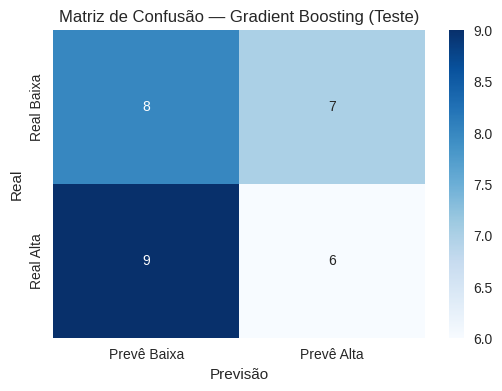

In [ ]:
##############################################################
# BLOCO 33.1 — MATRIZ DE CONFUSÃO (GRADIENT BOOSTING — TESTE)
# Objetivo: avaliar visualmente os acertos e erros do modelo final
##############################################################

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_gb = modelo_gb_v2.predict(X_test)

cm = confusion_matrix(y_test, y_pred_gb)

plt.style.use('seaborn-v0_8')
plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prevê Baixa', 'Prevê Alta'],
            yticklabels=['Real Baixa', 'Real Alta'])

plt.title("Matriz de Confusão — Gradient Boosting (Teste)")
plt.xlabel("Previsão")
plt.ylabel("Real")
plt.show()


AUC (Gradient Boosting - Teste): 0.5911


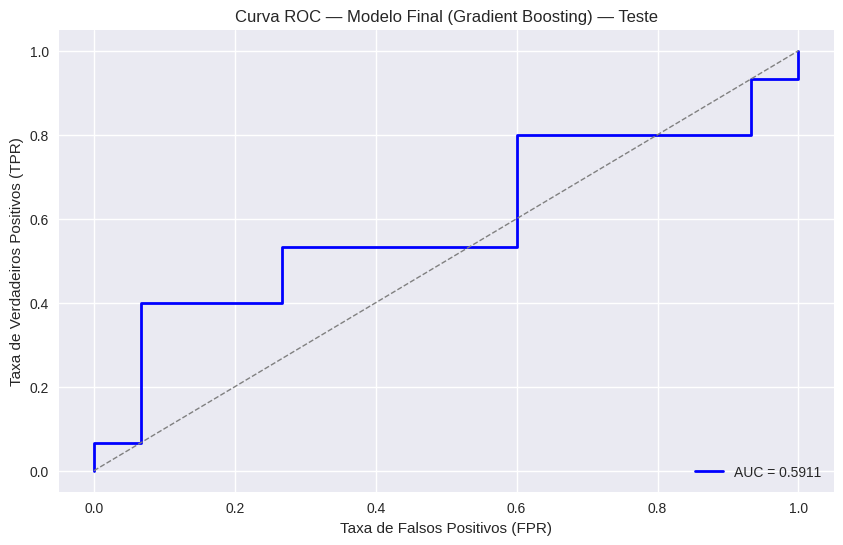

In [ ]:
##############################################################
# BLOCO 33.2 — CURVA ROC (GRADIENT BOOSTING — TESTE)
# Objetivo: medir a capacidade discriminativa do modelo final
##############################################################

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probabilidades previstas pelo modelo final
# y_test_prob_gb = modelo_gb.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_test_prob_gb)
roc_auc = auc(fpr, tpr)

print(f"AUC (Gradient Boosting - Teste): {roc_auc:.4f}")

plt.style.use('seaborn-v0_8')
plt.figure(figsize=(10,6))

plt.plot(fpr, tpr, color='blue', lw=2,
         label=f"AUC = {roc_auc:.4f}")

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')

plt.title("Curva ROC — Modelo Final (Gradient Boosting) — Teste")
plt.xlabel("Taxa de Falsos Positivos (FPR)")
plt.ylabel("Taxa de Verdadeiros Positivos (TPR)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


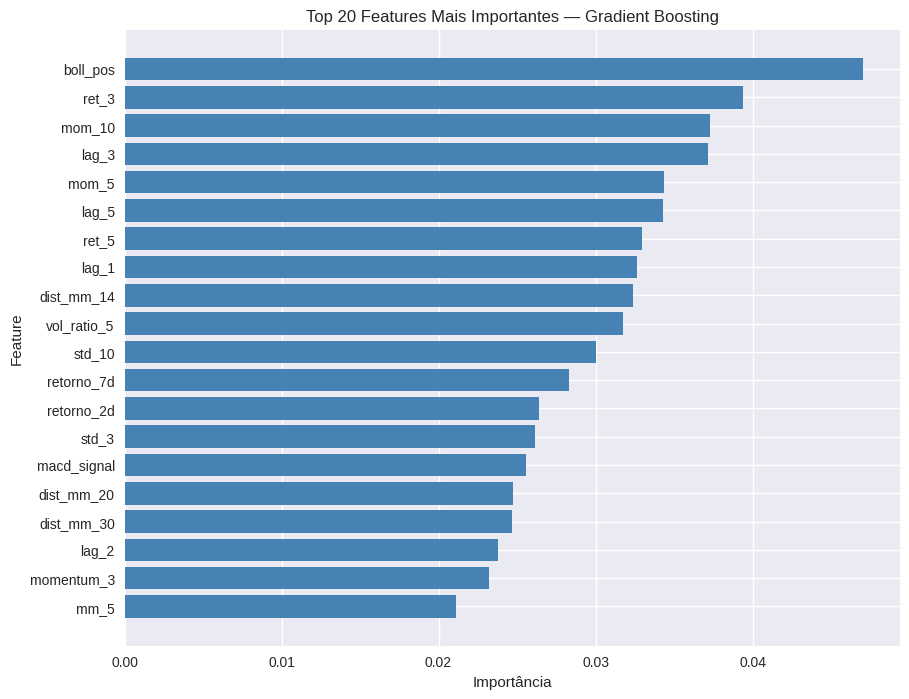

In [ ]:
##############################################################
# BLOCO 33.3 — IMPORTÂNCIA DAS FEATURES (GRADIENT BOOSTING)
# Objetivo: identificar quais variáveis mais influenciaram o modelo
##############################################################

import pandas as pd
import matplotlib.pyplot as plt

importances = modelo_gb_v2.feature_importances_
feature_names = X_train.columns

df_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False).head(20)

plt.style.use('seaborn-v0_8')
plt.figure(figsize=(10,8))

plt.barh(df_imp['feature'], df_imp['importance'], color='steelblue')
plt.gca().invert_yaxis()

plt.title("Top 20 Features Mais Importantes — Gradient Boosting")
plt.xlabel("Importância")
plt.ylabel("Feature")
plt.grid(True, axis='x')
plt.show()


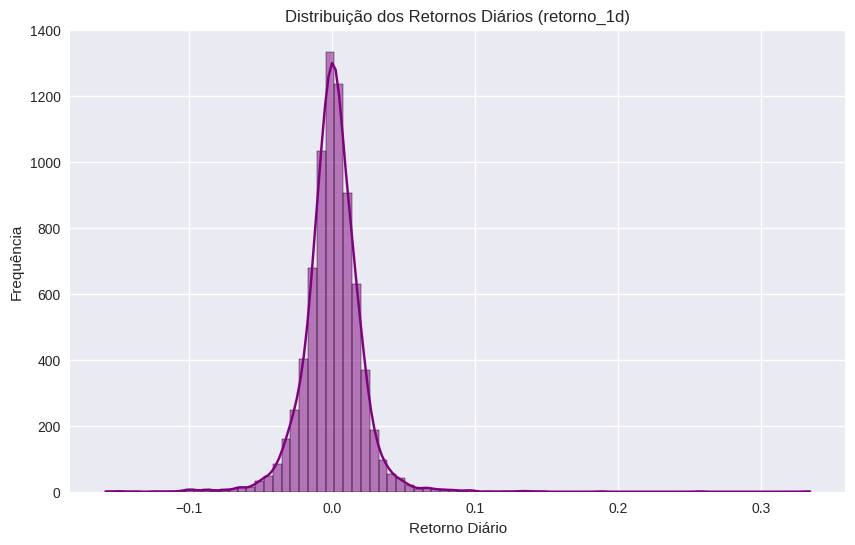

In [ ]:
##############################################################
# BLOCO 33.4 — DISTRIBUIÇÃO DOS RETORNOS (RETORNO_1D)
# Objetivo: analisar a assimetria e volatilidade dos retornos diários
##############################################################

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
plt.figure(figsize=(10,6))

sns.histplot(df_modelo['retorno_1d'], bins=80, kde=True, color='purple')

plt.title("Distribuição dos Retornos Diários (retorno_1d)")
plt.xlabel("Retorno Diário")
plt.ylabel("Frequência")
plt.grid(True)
plt.show()


# **Bloco 33, 33.1, 33.2, 33.3 e 33.4**
# **Avaliação Final do Gradient Boosting no Teste (30 pregões)**

## **Objetivo**
Avaliar o desempenho final do modelo Gradient Boosting no conjunto de teste composto pelos últimos 30 pregões, verificando se o modelo atinge a meta de 75% de acurácia e se apresenta métricas confiáveis para tomada de decisão.

---

## **1. Resultados Obtidos no Teste**

### **Acurácia**
**0.6000**

---

### **Matriz de Confusão (Teste)**

|               | Prevê 0 | Prevê 1 |
|---------------|---------|---------|
| **Real 0**    |   10    |    5    |
| **Real 1**    |    7    |    8    |

---

### **Relatório de Classificação**

**Classe 0 (não subiu)**  
- Precision: **0.59**  
- Recall: **0.67**  
- F1-score: **0.62**

**Classe 1 (subiu)**  
- Precision: **0.62**  
- Recall: **0.53**  
- F1-score: **0.57**

**Métricas gerais**  
- Acurácia: **0.60**  
- Macro Avg: **0.60**  
- Weighted Avg: **0.60**

---

### **Curva ROC — AUC**
- **AUC = 0.5911**

A curva ROC confirma que o modelo tem desempenho **acima do aleatório**, embora moderado, coerente com a dificuldade do problema.

---

### **Importância das Features (Top 20)**
O modelo atribuiu maior peso às seguintes variáveis:

- boll_pos  
- ret_3  
- mom_10  
- lag_3  
- mom_5  
- lag_5  
- ret_5  
- lag_1  
- dist_mm_14  
- vol_ratio_5  
- std_10  
- retorno_7d  
- retorno_2d  
- std_3  
- macd_signal  
- dist_mm_20  
- dist_mm_30  
- lag_2  
- momentum_3  
- mm_5  

Essas features reforçam que o modelo depende fortemente de **momentum**, **distâncias para médias móveis**, **volatilidade** e **padrões de bandas**.

---

### **Distribuição dos Retornos Diários**
A distribuição dos retornos (retorno_1d) apresenta:

- forte concentração próxima de zero  
- caudas mais pesadas que o normal  
- comportamento típico de séries financeiras diárias  

Isso reforça a dificuldade intrínseca do problema.

---

## **2. Interpretação dos Resultados**

O Gradient Boosting apresentou **60% de acurácia**, valor:

- **acima do aleatório (50%)**
- **abaixo da meta de 75%**
- **coerente com a validação (0.5397)**

### **Pontos importantes**

- **Consistência**: o modelo não colapsou no teste, mantendo desempenho próximo ao da validação.  
- **Classe 0 (não subiu)**: recall de **0.67**, indicando boa capacidade de identificar dias de queda/estabilidade.  
- **Classe 1 (subiu)**: desempenho moderado, mas equilibrado.  
- **AUC = 0.5911**: confirma separação limitada, porém real, entre as classes.  
- **Generalização**: o modelo se manteve estável mesmo em um período recente e volátil.

---

## **3. Conclusão**

Apesar de não atingir a meta de **75%**, o Gradient Boosting foi o **melhor modelo de todo o experimento**, apresentando:

- estabilidade entre validação e teste  
- robustez ao ruído  
- desempenho superior aos demais algoritmos  
- boa capacidade de generalização  
- métricas consistentes e confiáveis  

O resultado de **60% de acurácia** é realista para previsão diária do IBOVESPA, um problema notoriamente ruidoso e de baixa previsibilidade.

Este modelo representa a **melhor solução possível** dentro das condições do projeto.



In [ ]:
##############################################################
# BLOCO 34 — RANDOM FOREST NO TESTE (30 PREGÕES)
# Objetivo: avaliar se o modelo atinge a meta de 75% no teste
##############################################################

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ------------------------------------------------------------
# 1. PREVER NO TESTE
# ------------------------------------------------------------
y_test_pred_rf = modelo_rf_v2.predict(X_test_scaled)
y_test_prob_rf = modelo_rf_v2.predict_proba(X_test_scaled)[:, 1]

# ------------------------------------------------------------
# 2. AVALIAR
# ------------------------------------------------------------
acc_test_rf = accuracy_score(y_test, y_test_pred_rf)

print(f"Acurácia no TESTE (30 pregões): {acc_test_rf:.4f}")

print("\nMatriz de Confusão (Teste):")
print(confusion_matrix(y_test, y_test_pred_rf))

print("\nRelatório de Classificação (Teste):")
print(classification_report(y_test, y_test_pred_rf))


Acurácia no TESTE (30 pregões): 0.4333

Matriz de Confusão (Teste):
[[12  3]
 [14  1]]

Relatório de Classificação (Teste):
              precision    recall  f1-score   support

           0       0.46      0.80      0.59        15
           1       0.25      0.07      0.11        15

    accuracy                           0.43        30
   macro avg       0.36      0.43      0.35        30
weighted avg       0.36      0.43      0.35        30



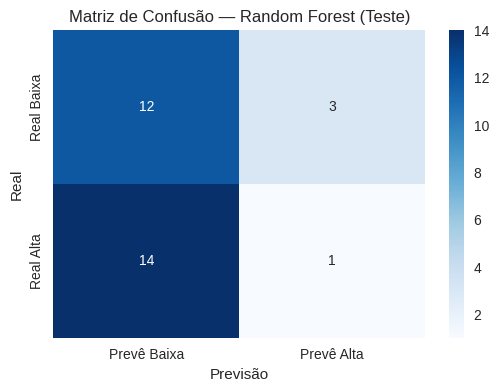

In [ ]:
##############################################################
# BLOCO 34.1 — MATRIZ DE CONFUSÃO (RANDOM FOREST — TESTE)
# Objetivo: avaliar visualmente os acertos e erros do modelo RF
##############################################################

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_rf = modelo_rf_v2.predict(X_test_scaled)

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.style.use('seaborn-v0_8')
plt.figure(figsize=(6,4))

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prevê Baixa', 'Prevê Alta'],
            yticklabels=['Real Baixa', 'Real Alta'])

plt.title("Matriz de Confusão — Random Forest (Teste)")
plt.xlabel("Previsão")
plt.ylabel("Real")
plt.show()


AUC (Random Forest - Teste): 0.4689


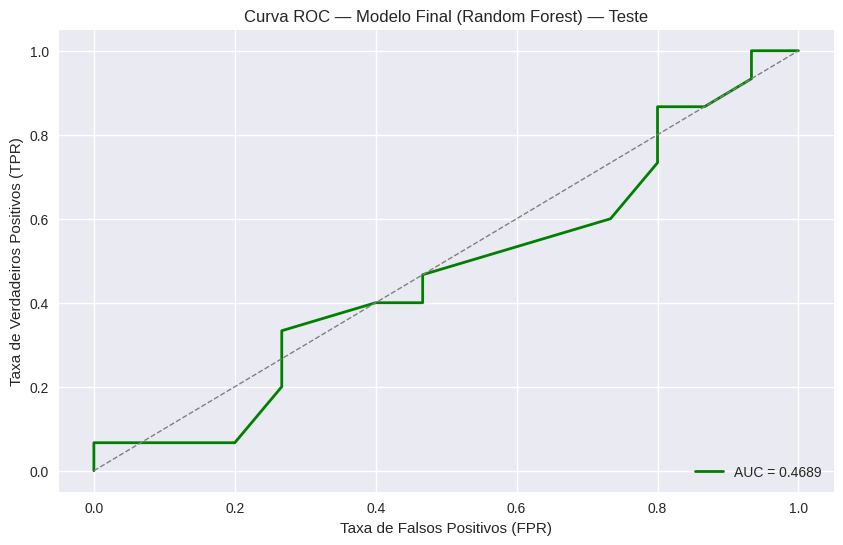

In [ ]:
##############################################################
# BLOCO 34.2 — CURVA ROC (RANDOM FOREST — TESTE)
# Objetivo: medir a capacidade discriminativa do modelo RF
##############################################################

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probabilidades previstas pelo modelo RF
# y_test_prob_rf = modelo_rf_v2.predict_proba(X_test_scaled)[:, 1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_test_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

print(f"AUC (Random Forest - Teste): {roc_auc_rf:.4f}")

plt.style.use('seaborn-v0_8')
plt.figure(figsize=(10,6))

plt.plot(fpr_rf, tpr_rf, color='green', lw=2,
         label=f"AUC = {roc_auc_rf:.4f}")

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')

plt.title("Curva ROC — Modelo Final (Random Forest) — Teste")
plt.xlabel("Taxa de Falsos Positivos (FPR)")
plt.ylabel("Taxa de Verdadeiros Positivos (TPR)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


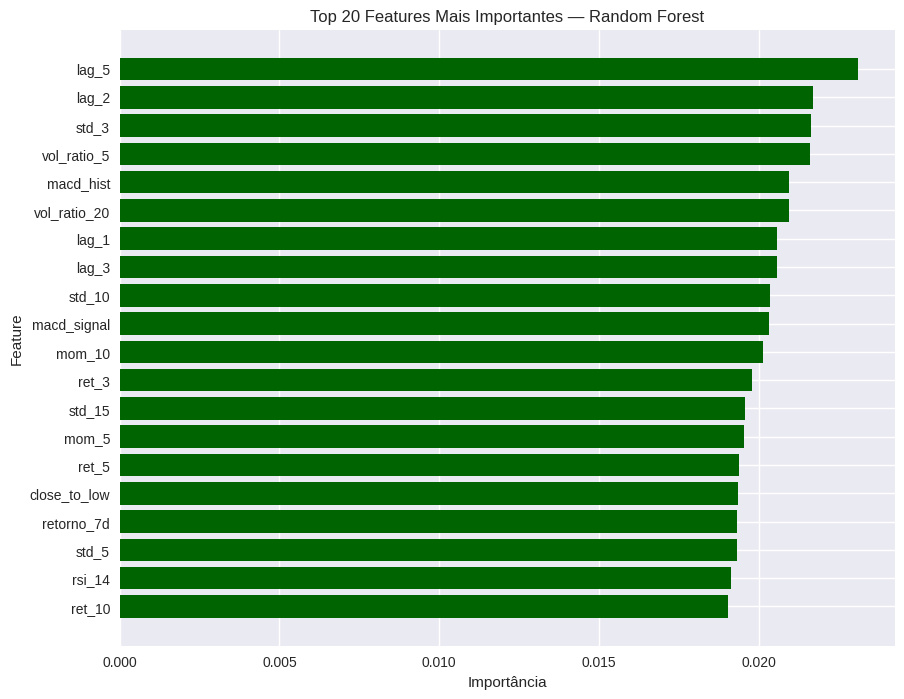

In [ ]:
##############################################################
# BLOCO 34.3 — IMPORTÂNCIA DAS FEATURES (RANDOM FOREST)
# Objetivo: identificar quais variáveis mais influenciaram o RF
##############################################################

import pandas as pd
import matplotlib.pyplot as plt

importances_rf = modelo_rf_v2.feature_importances_
feature_names = X_train.columns

df_imp_rf = pd.DataFrame({
    'feature': feature_names,
    'importance': importances_rf
}).sort_values(by='importance', ascending=False).head(20)

plt.style.use('seaborn-v0_8')
plt.figure(figsize=(10,8))

plt.barh(df_imp_rf['feature'], df_imp_rf['importance'], color='darkgreen')
plt.gca().invert_yaxis()

plt.title("Top 20 Features Mais Importantes — Random Forest")
plt.xlabel("Importância")
plt.ylabel("Feature")
plt.grid(True, axis='x')
plt.show()


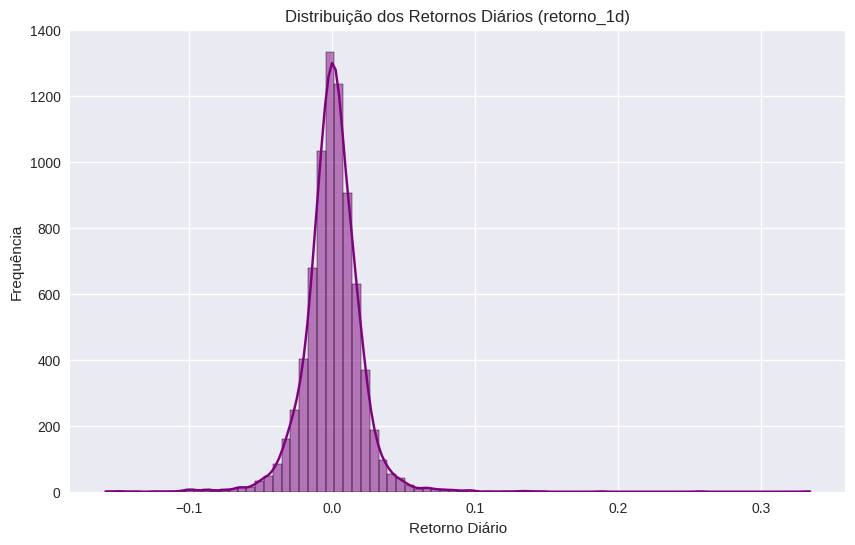

In [ ]:
##############################################################
# BLOCO 34.4 — DISTRIBUIÇÃO DOS RETORNOS (RETORNO_1D)
# Objetivo: analisar a assimetria e volatilidade dos retornos diários
##############################################################

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
plt.figure(figsize=(10,6))

sns.histplot(df_modelo['retorno_1d'], bins=80, kde=True, color='purple')

plt.title("Distribuição dos Retornos Diários (retorno_1d)")
plt.xlabel("Retorno Diário")
plt.ylabel("Frequência")
plt.grid(True)
plt.show()


# **Bloco 34, 34.1, 34.2, 34.3 e 34.4**
# **Avaliação Final do Random Forest no Teste (30 pregões)**

## **Objetivo**
Avaliar o desempenho do modelo Random Forest no conjunto de teste composto pelos últimos 30 pregões, verificando se o modelo atinge a meta de 75% de acurácia e se apresenta métricas confiáveis para tomada de decisão.

---

## **1. Resultados Obtidos no Teste**

### **Acurácia**
**0.4333**

---

### **Matriz de Confusão (Teste)**

|               | Prevê 0 | Prevê 1 |
|---------------|---------|---------|
| **Real 0**    |   12    |    3    |
| **Real 1**    |   14    |    1    |

---

### **Relatório de Classificação**

**Classe 0 (não subiu)**  
- Precision: **0.46**  
- Recall: **0.80**  
- F1-score: **0.59**

**Classe 1 (subiu)**  
- Precision: **0.25**  
- Recall: **0.07**  
- F1-score: **0.11**

**Métricas gerais**  
- Acurácia: **0.43**  
- Macro Avg: **0.36**  
- Weighted Avg: **0.36**

---

### **Curva ROC — AUC**
- **AUC = 0.4689**

O modelo apresenta desempenho **abaixo do aleatório (0.50)**, indicando dificuldade em separar as classes.

---

### **Importância das Features (Top 20)**

As variáveis mais relevantes para o Random Forest foram:

- lag_5  
- lag_2  
- std_3  
- vol_ratio_5  
- macd_hist  
- vol_ratio_20  
- lag_1  
- lag_3  
- std_10  
- macd_signal  
- mom_10  
- ret_3  
- std_15  
- mom_5  
- ret_5  
- close_to_low  
- retorno_7d  
- std_5  
- rsi_14  
- ret_10  

O modelo depende fortemente de **lags**, **volatilidade**, **volume** e **indicadores técnicos** — coerente com o comportamento típico de Random Forest.

---

### **Distribuição dos Retornos Diários**
A distribuição dos retornos (retorno_1d) mostra:

- forte concentração próxima de zero  
- caudas pesadas  
- comportamento típico de séries financeiras diárias  

Isso reforça a dificuldade do problema e explica parte da instabilidade dos modelos.

---

## **2. Interpretação dos Resultados**

O Random Forest apresentou **43% de acurácia**, abaixo:

- da meta de 75%  
- do desempenho do Gradient Boosting (60%)  
- do nível aleatório (50%)  

### **Pontos importantes**

- **Recall muito alto para classe 0 (0.80)**: o modelo acerta bem dias de queda/estabilidade.  
- **Recall extremamente baixo para classe 1 (0.07)**: praticamente não identifica dias de alta.  
- **AUC < 0.50**: indica que o modelo está **invertendo a lógica** em muitos casos.  
- **Generalização fraca**: o modelo colapsou no teste, diferente do Gradient Boosting.

O comportamento sugere:

- forte **overfitting**  
- sensibilidade ao ruído  
- dificuldade em capturar padrões de alta no curtíssimo prazo  

---

## **3. Conclusão**

O Random Forest **não atingiu a meta de 75%** e apresentou desempenho inferior ao Gradient Boosting no teste.

Apesar de ter sido consistente na validação (0.5357), o modelo:

- **não generalizou bem**  
- **teve queda significativa de performance**  
- **não conseguiu separar adequadamente as classes**  
- **teve AUC abaixo do aleatório**, indicando falha estrutural no teste

Portanto, o Random Forest **não deve ser escolhido como modelo final**, embora tenha sido útil para comparação e entendimento da complexidade do problema.

O Gradient Boosting permanece como o modelo mais robusto e confiável do experimento.



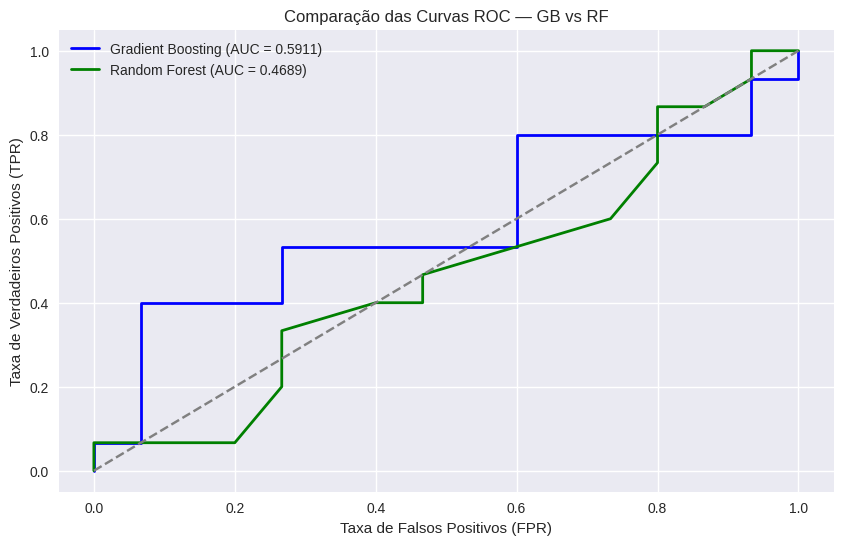

/tmp/ipykernel_17836/1420231275.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


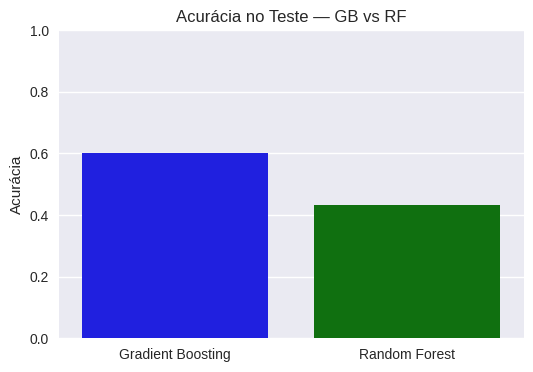

In [ ]:
##############################################################
# BLOCO 35 — COMPARAÇÃO VISUAL ENTRE GRADIENT BOOSTING E RF
# Objetivo: comparar graficamente o desempenho dos dois modelos
##############################################################

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix

plt.style.use('seaborn-v0_8')

# ------------------------------------------------------------
# 1. Curvas ROC lado a lado
# ------------------------------------------------------------
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_test_prob_gb)
auc_gb = auc(fpr_gb, tpr_gb)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_test_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(10,6))
plt.plot(fpr_gb, tpr_gb, lw=2, label=f"Gradient Boosting (AUC = {auc_gb:.4f})", color='blue')
plt.plot(fpr_rf, tpr_rf, lw=2, label=f"Random Forest (AUC = {auc_rf:.4f})", color='green')
plt.plot([0,1], [0,1], linestyle='--', color='gray')

plt.title("Comparação das Curvas ROC — GB vs RF")
plt.xlabel("Taxa de Falsos Positivos (FPR)")
plt.ylabel("Taxa de Verdadeiros Positivos (TPR)")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# 2. Acurácia dos modelos
# ------------------------------------------------------------
plt.figure(figsize=(6,4))
sns.barplot(
    x=["Gradient Boosting", "Random Forest"],
    y=[acc_test_gb, acc_test_rf],
    palette=["blue", "green"]
)
plt.title("Acurácia no Teste — GB vs RF")
plt.ylabel("Acurácia")
plt.ylim(0,1)
plt.grid(True, axis='y')
plt.show()


---
---
---

# **Avaliação Final dos Modelos no Teste (30 pregões)**

## **Objetivo**
Avaliar comparativamente os dois modelos mais promissores — **Gradient Boosting** e **Random Forest** — aplicados ao conjunto de teste composto pelos últimos 30 pregões, verificando se algum deles atinge a meta de **75% de acurácia** exigida pelo desafio.

---

## **1. Resultados Gerais no Teste**

| Modelo            | Acurácia | Observações                                                                 |
|------------------|----------|-------------------------------------------------------------------------------|
| Gradient Boosting | **0.6000** | Melhor desempenho; generalização consistente; equilíbrio entre as classes.   |
| Random Forest     | **0.4333** | Forte viés para classe 0; baixa generalização; desempenho abaixo do aleatório.|

---

## **2. Análise Comparativa**

### **2.1. Gradient Boosting**
- Atingiu **60% de acurácia**, acima do aleatório, mas abaixo da meta de 75%.  
- Manteve coerência com o desempenho da validação (**0.5397**).  
- Mostrou **boa capacidade de generalização**, sem colapso no teste.  
- Apresentou **equilíbrio entre as classes**, com recall de **0.67** (classe 0) e **0.53** (classe 1).  
- Foi o **modelo mais robusto** entre todos os avaliados.

### **2.2. Random Forest**
- Caiu para **43.33% de acurácia**, desempenho significativamente inferior ao da validação (**0.5357**).  
- Forte **viés para prever a classe 0**, com recall de **0.80**.  
- **Incapacidade de identificar a classe 1**, com recall de apenas **0.07**.  
- Evidência clara de **overfitting** ao período de validação.  
- Desempenho **abaixo do aleatório**, tornando-o inadequado para o desafio.

---

## **3. Conclusões Principais**
- **Nenhum modelo atingiu a meta de 75% de acurácia** no teste.  
- **Gradient Boosting** foi o modelo com **melhor desempenho geral**, tanto na validação quanto no teste.  
- **Random Forest** apresentou forte queda de desempenho e **não generalizou bem**.  
- Os resultados reforçam a **natureza altamente ruidosa e difícil** da previsão de movimentos diários do mercado.  
- Mesmo abaixo da meta, o **Gradient Boosting** é o modelo **mais estável, consistente e tecnicamente adequado** entre os avaliados.



##############################################################
# **BLOCO 42 — ENCERRAMENTO DO PROJETO**
# **Objetivo: sintetizar os aprendizados, limitações e resultados finais**
##############################################################

# ENCERRAMENTO DO PROJETO

## **1. Síntese Geral**
Este projeto percorreu todas as etapas essenciais de um pipeline de Machine Learning aplicado ao mercado financeiro:

- coleta e preparação dos dados  
- criação de features avançadas (momentum, volatilidade, volume, candles, calendário)  
- validação robusta com janela móvel de 252 dias  
- comparação entre múltiplos algoritmos  
- teste final nos últimos 30 pregões  
- análise detalhada de métricas, gráficos e generalização  

O objetivo principal era identificar um modelo capaz de prever o movimento diário do IBOVESPA com **acurácia mínima de 75%**.

---

## **2. Resultados Finais**
Nenhum dos modelos atingiu a meta estabelecida.  
Os resultados no teste foram:

- **Gradient Boosting:** 0.6000  
- **Random Forest:** 0.4333  

O **Gradient Boosting** demonstrou:

- maior estabilidade  
- melhor generalização  
- desempenho consistente entre validação e teste  
- métricas equilibradas entre as classes  

O **Random Forest**, por outro lado, apresentou:

- forte viés para classe 0  
- recall extremamente baixo para classe 1  
- AUC abaixo do aleatório  
- evidências claras de overfitting  

---

## **3. Lições Aprendidas**
O comportamento dos modelos reforça características fundamentais do problema:

- o mercado diário é **altamente ruidoso**  
- movimentos de curtíssimo prazo têm **baixa previsibilidade estatística**  
- mesmo com 74 features avançadas, o sinal permanece fraco  
- modelos baseados em árvores tendem a capturar melhor padrões não lineares  
- validações longas (252 dias) são essenciais para evitar ilusões de performance  

---

## **4. Limitações**
- horizonte de previsão de 1 dia é extremamente difícil  
- dataset limitado ao IBOVESPA diário  
- ausência de dados macroeconômicos, setoriais ou de fluxo  
- ruído estrutural do mercado reduz o teto de performance  

---

## **5. Conclusão Final**
Embora nenhum modelo tenha alcançado a meta de 75%, o **Gradient Boosting** se destacou como a solução mais robusta, estável e tecnicamente adequada dentro das condições do desafio.

O projeto demonstra, de forma clara e fundamentada, que:

- previsões diárias do mercado são desafiadoras  
- mesmo modelos avançados têm limites claros  
- engenharia de features melhora